# EDA

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/etna-team/etna/master?filepath=examples/103-EDA.ipynb)

This notebook contains the simple examples of EDA (exploratory data analysis) using ETNA library.

**Table of contents**

* [Loading dataset](#chapter1)  
* [Visualization](#chapter2)
    * [Plotting time series](#section_2_1)
    * [Autocorrelation & partial autocorrelation](#section_2_2)
    * [Cross-correlation](#section_2_3)
    * [Correlation heatmap](#section_2_4)
    * [Distribution](#section_2_5)
    * [Trend](#section_2_6)
    * [Seasonality](#section_2_7)
* [Outliers](#chapter3)
    * [Median method](#section_3_1)
    * [Density method](#section_3_2)
* [Change Points](#chapter4)    

In [1]:
!pip install "etna[prophet]" -q
!pip uninstall prophet -y -q
!pip install "prophet>=1.1.5" -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.2/565.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

from etna.datasets.tsdataset import TSDataset
from etna.transforms import LagTransform
from etna.transforms import LinearTrendTransform

## 1. Loading dataset <a class="anchor" id="chapter1"></a>

Let's load and look at the dataset

In [3]:
!wget https://raw.githubusercontent.com/tinkoff-ai/etna/refs/heads/master/examples/data/example_dataset.csv

--2025-11-05 06:03:31--  https://raw.githubusercontent.com/tinkoff-ai/etna/refs/heads/master/examples/data/example_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33422 (33K) [text/plain]
Saving to: ‘example_dataset.csv’

example_dataset.csv 100%[===================>]  32.64K  --.-KB/s    in 0.003s  

2025-11-05 06:03:31 (12.7 MB/s) - ‘example_dataset.csv’ saved [33422/33422]



In [4]:
df = pd.read_csv("/content/example_dataset.csv")
df.head()

,timestamp,segment,target
0,2019-01-01,segment_a,170
1,2019-01-02,segment_a,243
2,2019-01-03,segment_a,267
3,2019-01-04,segment_a,287
4,2019-01-05,segment_a,279


Our library works with the special data structure `TSDataset`. Let's create it as it was done in "Get started" notebook.

In [5]:
ts = TSDataset(df, freq="D")
ts.head(5)

segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-01-01,170.0,102.0,92.0,238.0
2019-01-02,243.0,123.0,107.0,358.0
2019-01-03,267.0,130.0,103.0,366.0
2019-01-04,287.0,138.0,103.0,385.0
2019-01-05,279.0,137.0,104.0,384.0


`TSDataset` has its own implementations of `describe` and `info` methods that gives information about distinct time series.

In [6]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
segment_a,2019-01-01,2019-11-30,334,0,4,0,0,0,D
segment_b,2019-01-01,2019-11-30,334,0,4,0,0,0,D
segment_c,2019-01-01,2019-11-30,334,0,4,0,0,0,D
segment_d,2019-01-01,2019-11-30,334,0,4,0,0,0,D


In [7]:
ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 4
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2019-11-30 00:00:00
          start_timestamp  length  num_missing
segments                                      
segment_a      2019-01-01     334            0
segment_b      2019-01-01     334            0
segment_c      2019-01-01     334            0
segment_d      2019-01-01     334            0


## 2. Visualization <a class="anchor" id="chapter2"></a>

Our library provides a list of utilities for visual data exploration. So, having the dataset converted to `TSDataset`, now we can visualize it.

In [8]:
from etna.analysis import acf_plot
from etna.analysis import cross_corr_plot
from etna.analysis import distribution_plot
from etna.analysis import plot_correlation_matrix

### 2.1 Plotting time series <a class="anchor" id="section_2_1"></a>

Let's take a look at the time series in the dataset

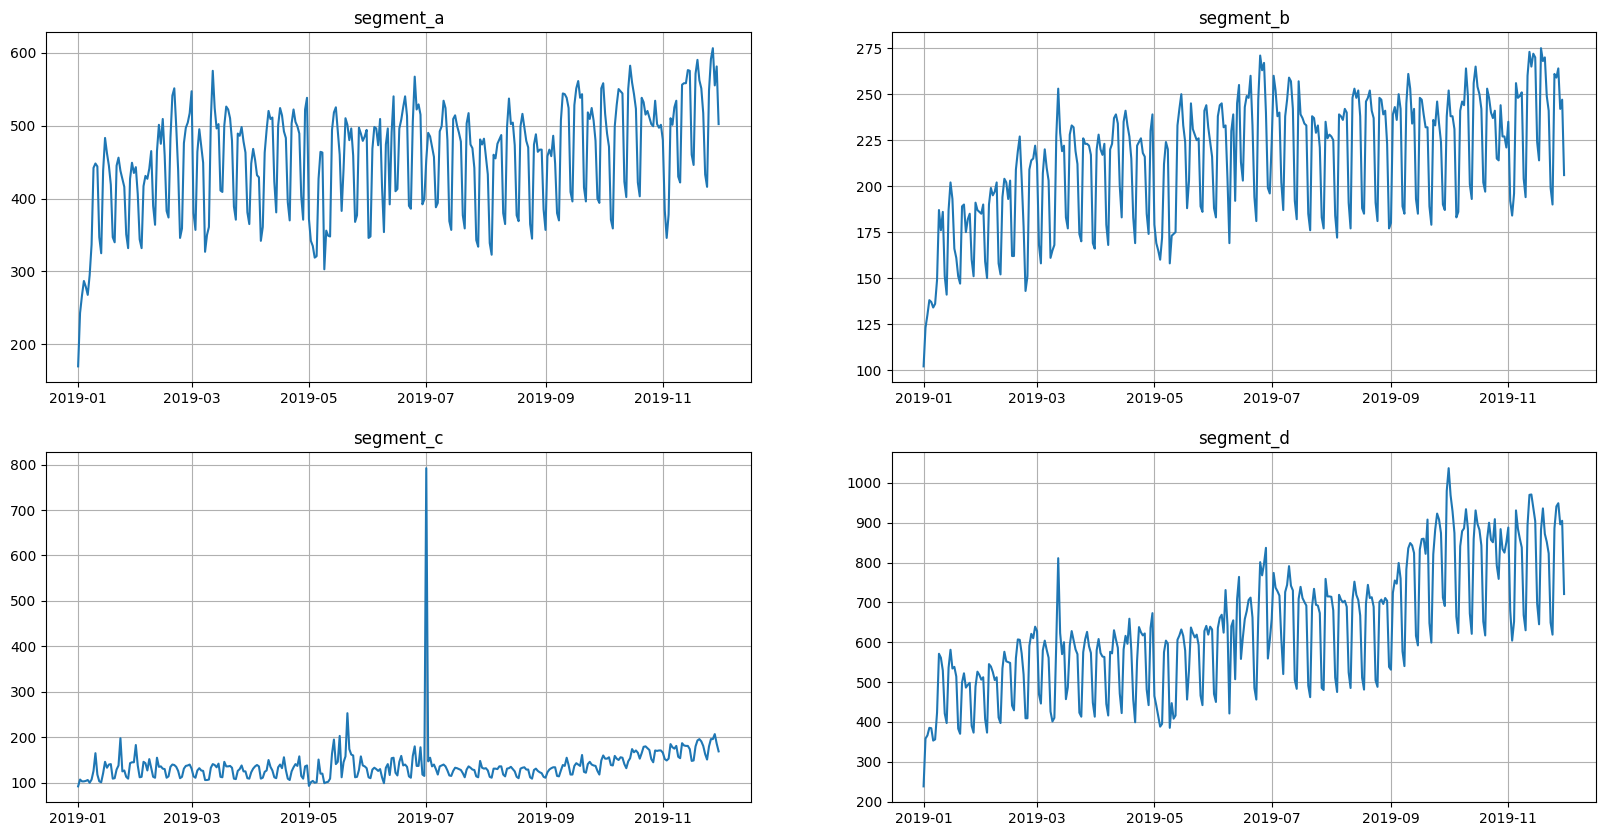

In [9]:
ts.plot()

### 2.2 Autocorrelation & partial autocorrelation<a class="anchor" id="section_2_2"></a>

Autocorrelation function (**ACF**, $\rho(\tau)$) describes the relationship between $y_t$ and $y_{t + \tau}$. The AFC plot can help to identify the extent of the lag in moving average models.

Partial autocorrelation function (**PACF**, $\gamma(\tau)$) describes the relationship between $y_t$ and $y_{t + \tau}$ cleaned from the influence of $y_{t+1},\dots,\ y_{t + \tau - 1}$. The PAFC plot can help to identify the extent of the lag in autoregressive models.

Let's observe the ACF and PACF plot for our time series, specifying the maximum number of lags

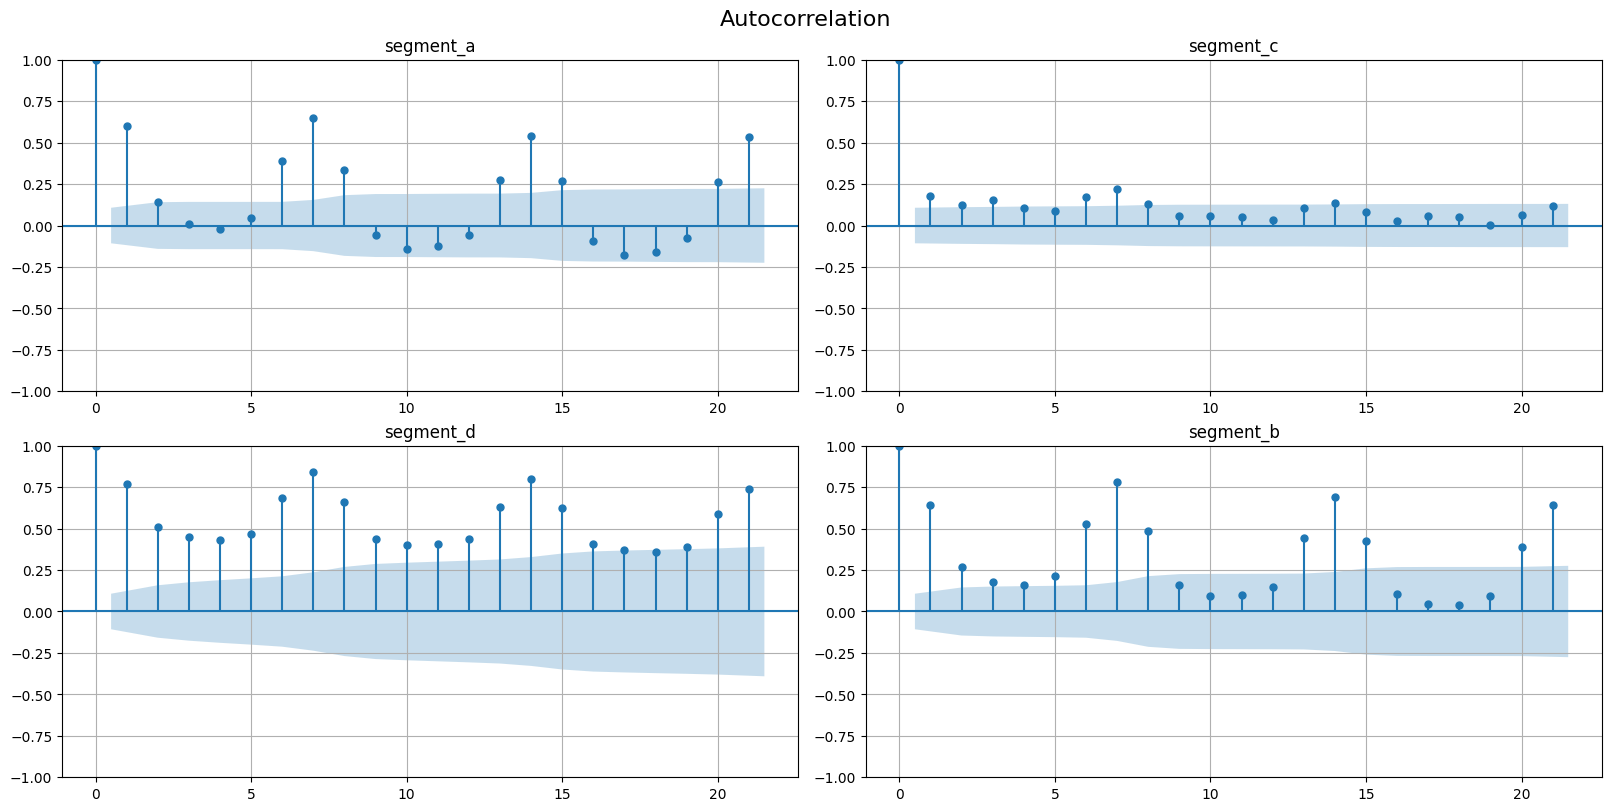

In [12]:
acf_plot(ts,
         lags=21, # number of timeseries shifts for cross-correlation
         partial=False, # plot autocorrelation or partial autocorrelation
         figsize=(8,4)
)
# видна периодичность в 7 дней (расстояние между максимальными пиками)

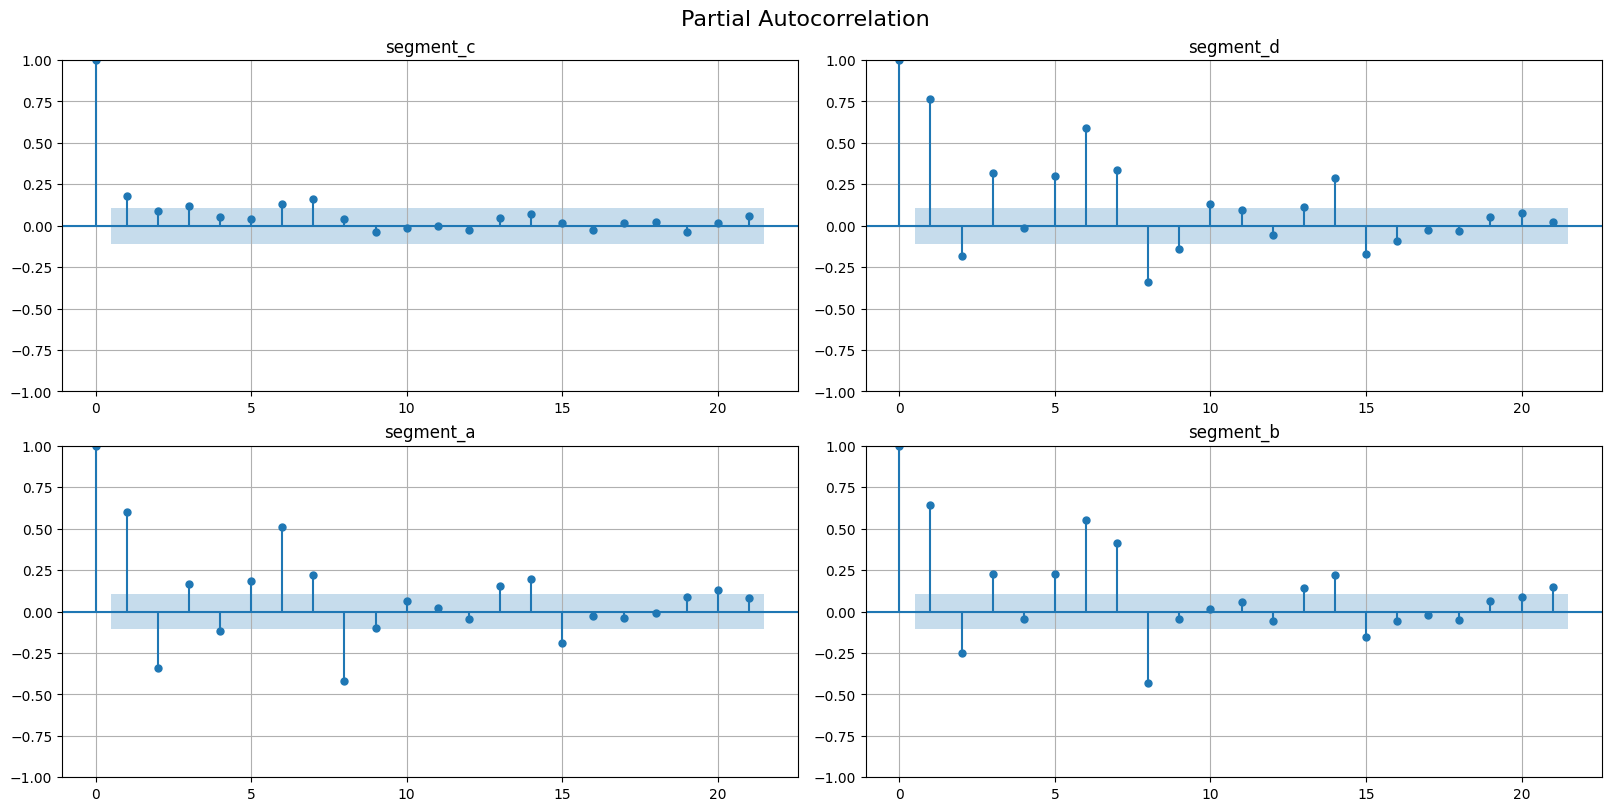

In [13]:
acf_plot(ts,
         lags=21,
         partial=True,
         figsize=(8,4)
)

### 2.3 Cross-correlation<a class="anchor" id="section_2_3"></a>

Cross-correlation is generally used to compare multiple time series and determine how well they match up with each other and, in particular, at what point the best match occurs. The closer the cross-correlation value is to $1$, the more closely the sets are identical.

Let's plot the cross-correlation for all pairs of time series in our dataset


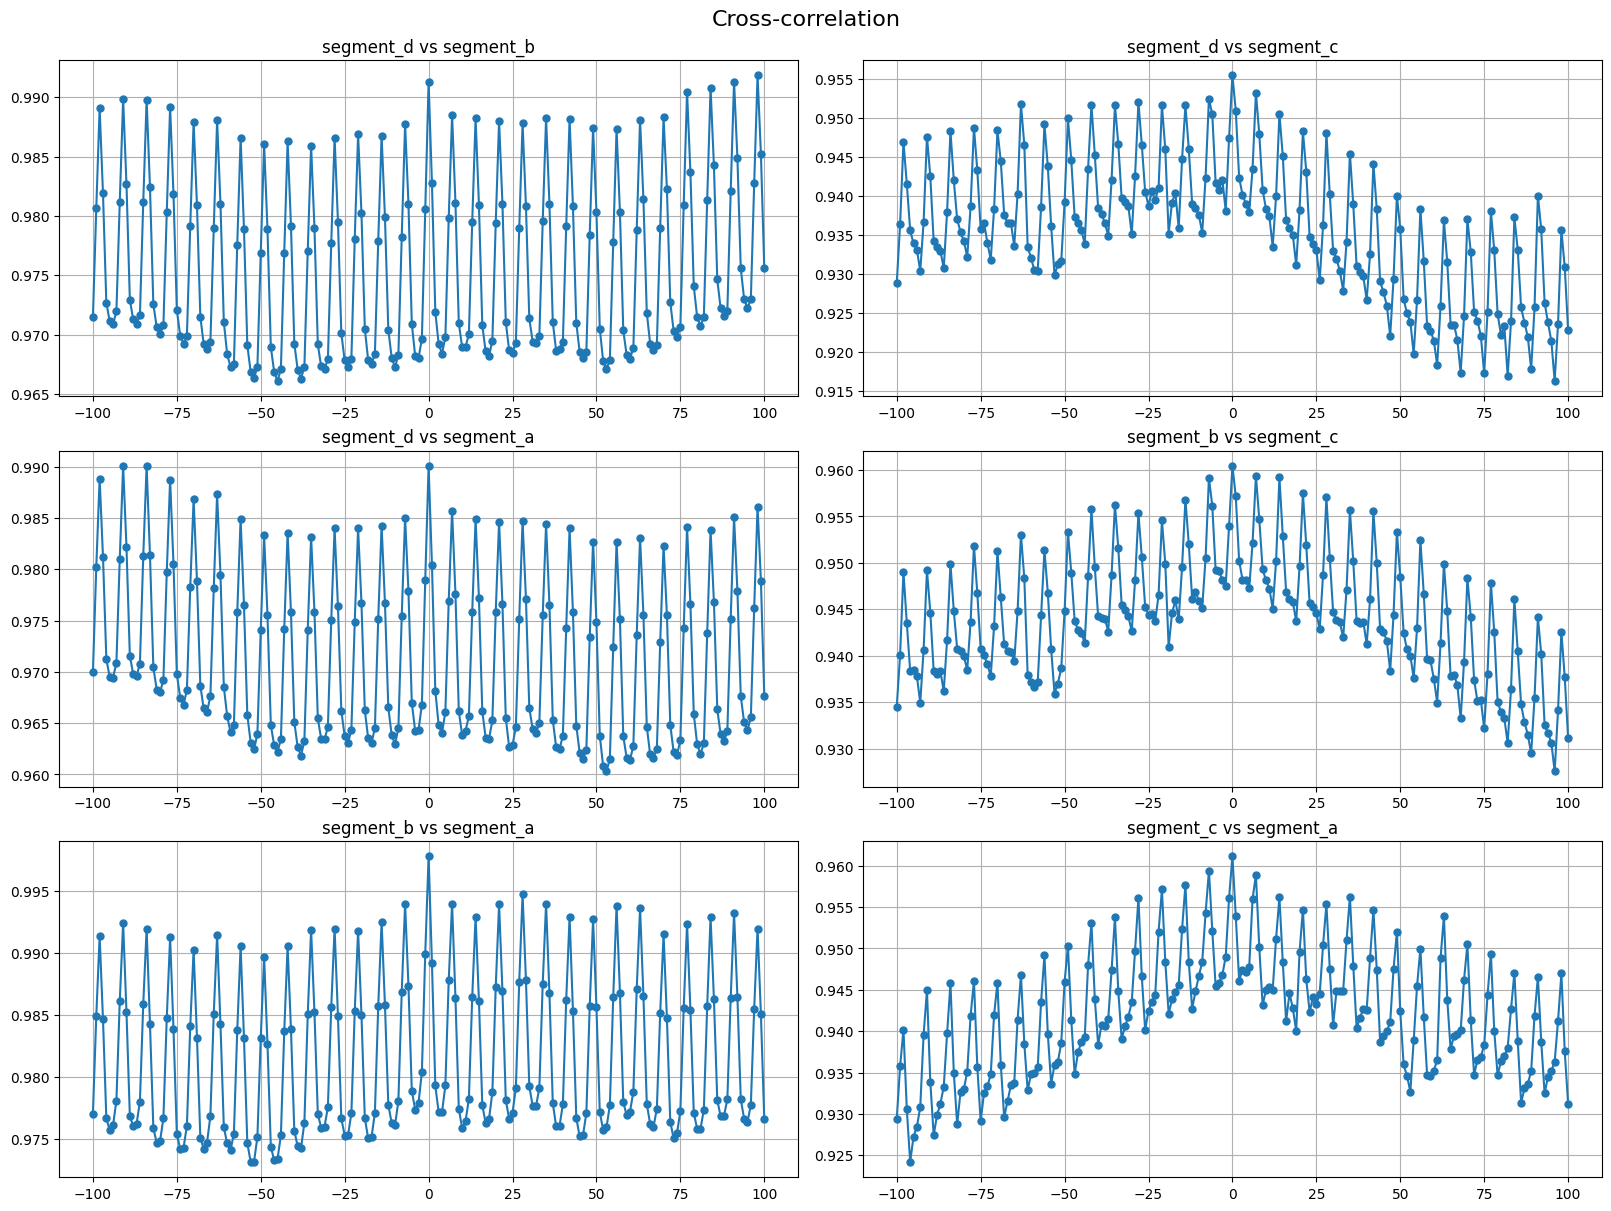

In [14]:
cross_corr_plot(
    ts,
    # maxlags
    # number of timeseries shifts for cross-correlation,
    # should be >=1 and <= len(timeseries)
    maxlags=100,
    figsize=(8,4)
)

### 2.4 Correlation heatmap <a class="anchor" id="section_2_4"></a>

Correlation heatmap is a visualization of pairwise correlation matrix between timeseries in a dataset. It is a simple visual tool which you may use to determine the correlated timeseries in your dataset.

Let's take a look at the correlation heatmap, adding lags columns to the dataset to catch the series that are correlated but with some shift.

In [15]:
ts.to_pandas()

segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-01-01,170.0,102.0,92.0,238.0
2019-01-02,243.0,123.0,107.0,358.0
2019-01-03,267.0,130.0,103.0,366.0
2019-01-04,287.0,138.0,103.0,385.0
2019-01-05,279.0,137.0,104.0,384.0
...,...,...,...,...
2019-11-26,591.0,259.0,196.0,941.0
2019-11-27,606.0,264.0,196.0,949.0


In [16]:
lags = LagTransform(
    in_column="target",
    lags=[1, 7],
    out_column="lag"
)
ts.fit_transform([lags])

In [17]:
ts.to_pandas()

segment    segment_a               segment_b               segment_c         \
feature        lag_1  lag_7 target     lag_1  lag_7 target     lag_1  lag_7   
timestamp                                                                     
2019-01-01       NaN    NaN  170.0       NaN    NaN  102.0       NaN    NaN   
2019-01-02     170.0    NaN  243.0     102.0    NaN  123.0      92.0    NaN   
2019-01-03     243.0    NaN  267.0     123.0    NaN  130.0     107.0    NaN   
2019-01-04     267.0    NaN  287.0     130.0    NaN  138.0     103.0    NaN   
2019-01-05     287.0    NaN  279.0     138.0    NaN  137.0     103.0    NaN   
...              ...    ...    ...       ...    ...    ...       ...    ...   
2019-11-26     548.0  590.0  591.0     261.0  268.0  259.0     180.0  193.0   
2019-11-27     591.0  562.0  606.0     259.0  270.0  264.0     196.0  196.0   
2019-11-28     606.0  551.0  555.0     264.0  249.0  242.0     196.0  191.0   
2019-11-29     555.0  517.0  581.0     242.0  241.0  247.0     207.0  181.0   
2019-11-30     581.0  433.0  502.0     247.0  199.0  206.0     186.0  163.0   

segment           segment_d                
feature    target     lag_1  lag_7 target  
timestamp                                  
2019-01-01   92.0       NaN    NaN  238.0  
2019-01-02  107.0     238.0    NaN  358.0  
2019-01-03  103.0     358.0    NaN  366.0  
2019-01-04  103.0     366.0    NaN  385.0  
2019-01-05  104.0     385.0    NaN  384.0  
...           ...       ...    ...    ...  
2019-11-26  196.0     886.0  936.0  941.0  
2019-11-27  196.0     941.0  872.0  949.0  
2019-11-28  207.0     949.0  852.0  896.0  
2019-11-29  186.0     896.0  823.0  905.0  
2019-11-30  169.0     905.0  649.0  721.0  

[334 rows x 12 columns]

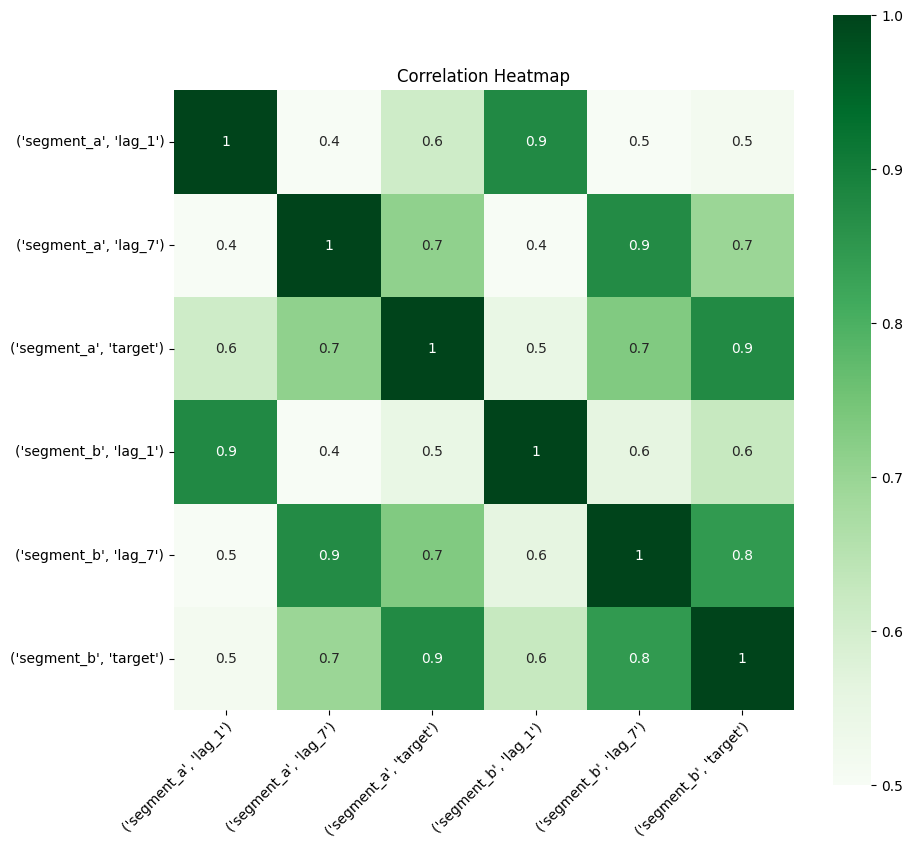

In [20]:
plot_correlation_matrix(
    ts,
    segments=["segment_a", "segment_b"],
    method="spearman", # pearson, kendall
    vmin=0.5,
    vmax=1,
    cmap="Greens"
)
# pearson:  standard correlation coefficient
# kendall:  Kendall Tau correlation coefficient
# spearman: Spearman rank correlation

### 2.5 Distribution <a class="anchor" id="section_2_5"></a>

Distribution of z-values grouped by segments and time frequency. Using this plot, you can monitor the data drifts over time.

Let's compare the distributions over each year in the dataset

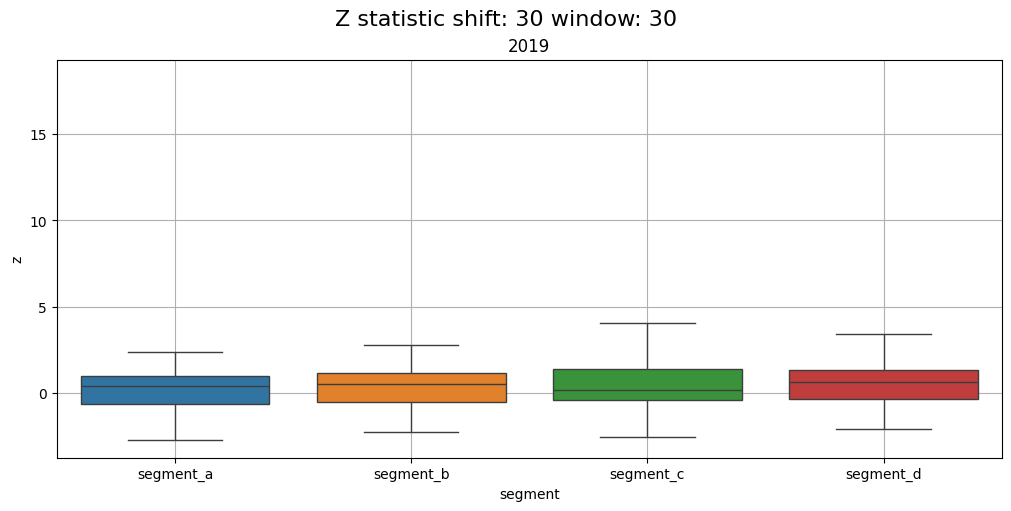

In [21]:
distribution_plot(
    ts,
    freq="1Y",
    shift=30, # number of timeseries shifts for statistics calc
    window=30 # number of points for statistics calc
)

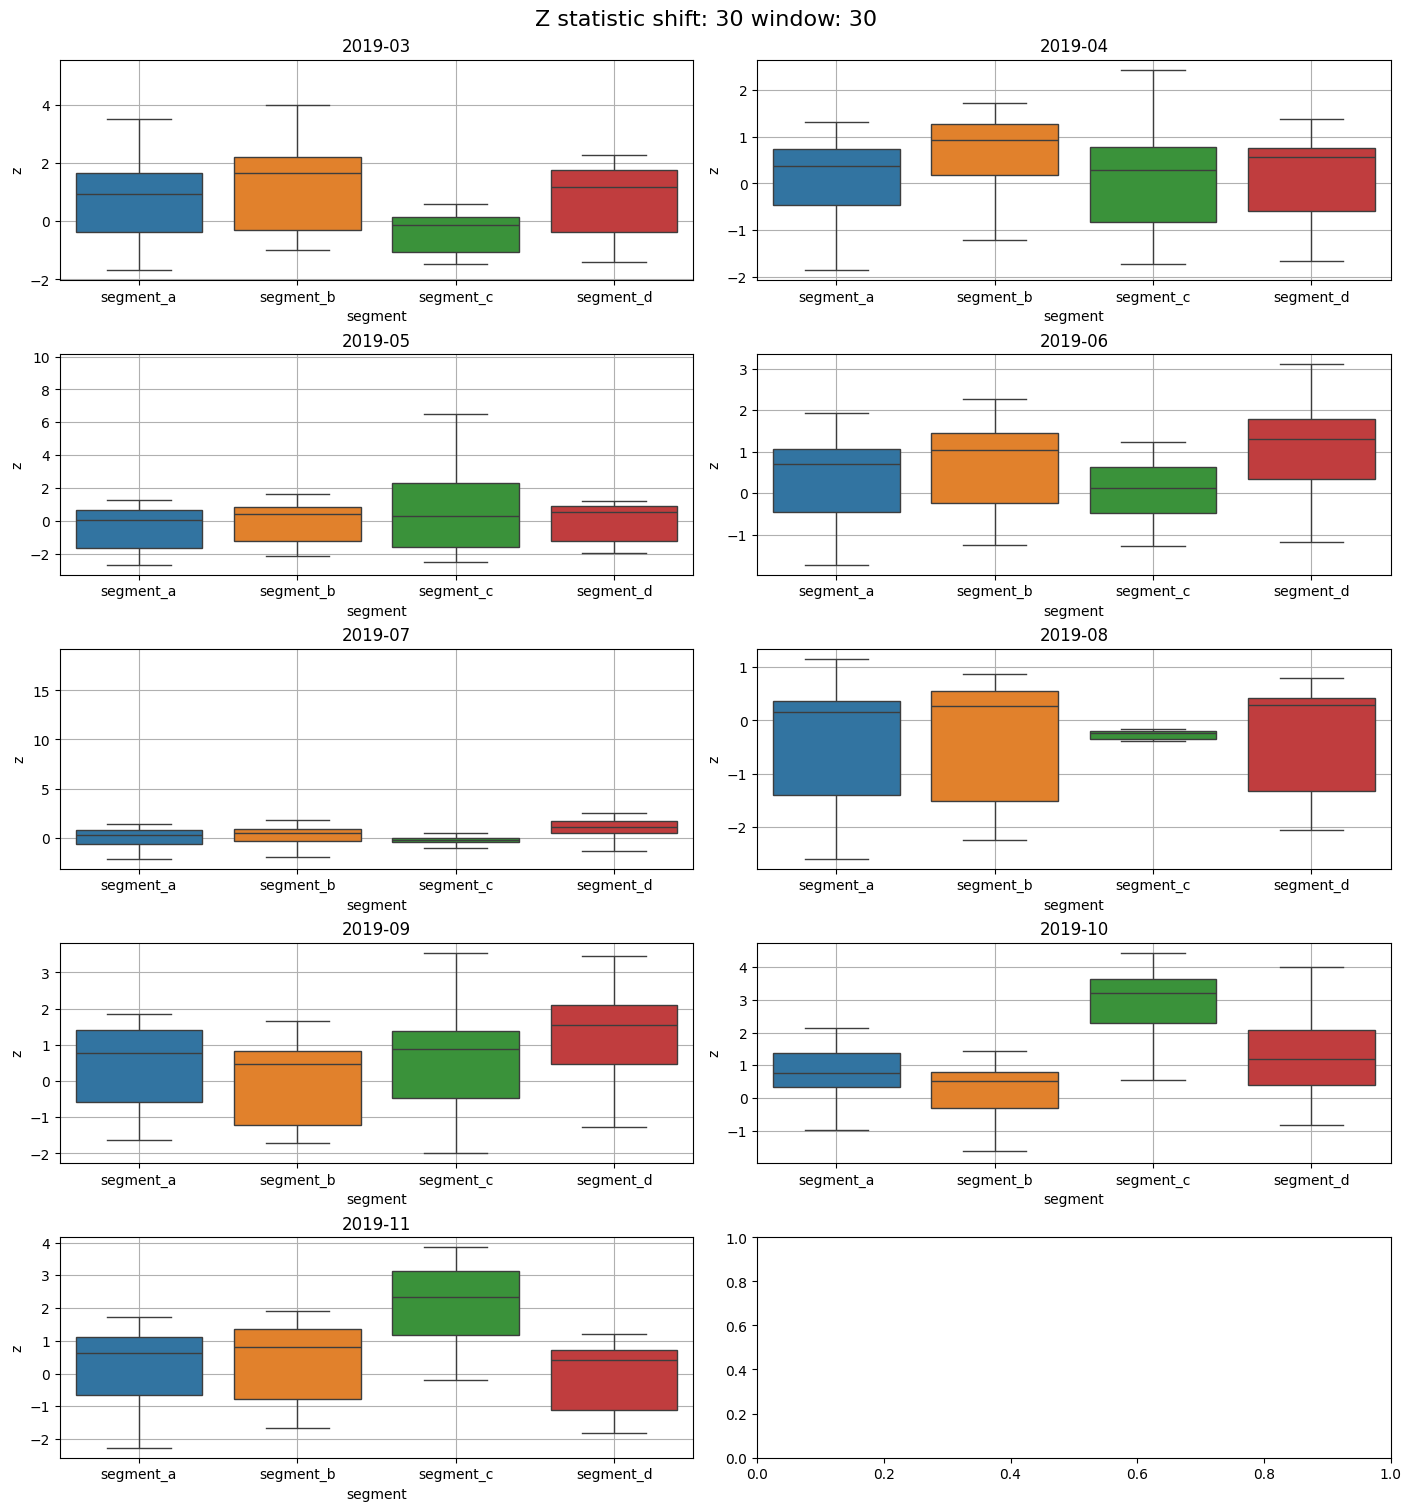

In [24]:
distribution_plot(
    ts,
    # freq="1Y",
    shift=30, # number of timeseries shifts for statistics calc
    window=30, # number of points for statistics calc
    figsize=(7, 3)
)

### 2.6 Trend <a class="anchor" id="section_2_6"></a>

Time series have such an important characteristic as a trend. Using `plot_trend`, you can visualize the trend for each segment and select the appropriate model to describe it.

For example, let's build a linear and parabolic trend.

In [25]:
from etna.analysis import plot_trend

In [29]:
trends = [
    LinearTrendTransform(in_column="target", poly_degree=1),
    LinearTrendTransform(in_column="target", poly_degree=2),
    LinearTrendTransform(in_column="target", poly_degree=3),
]

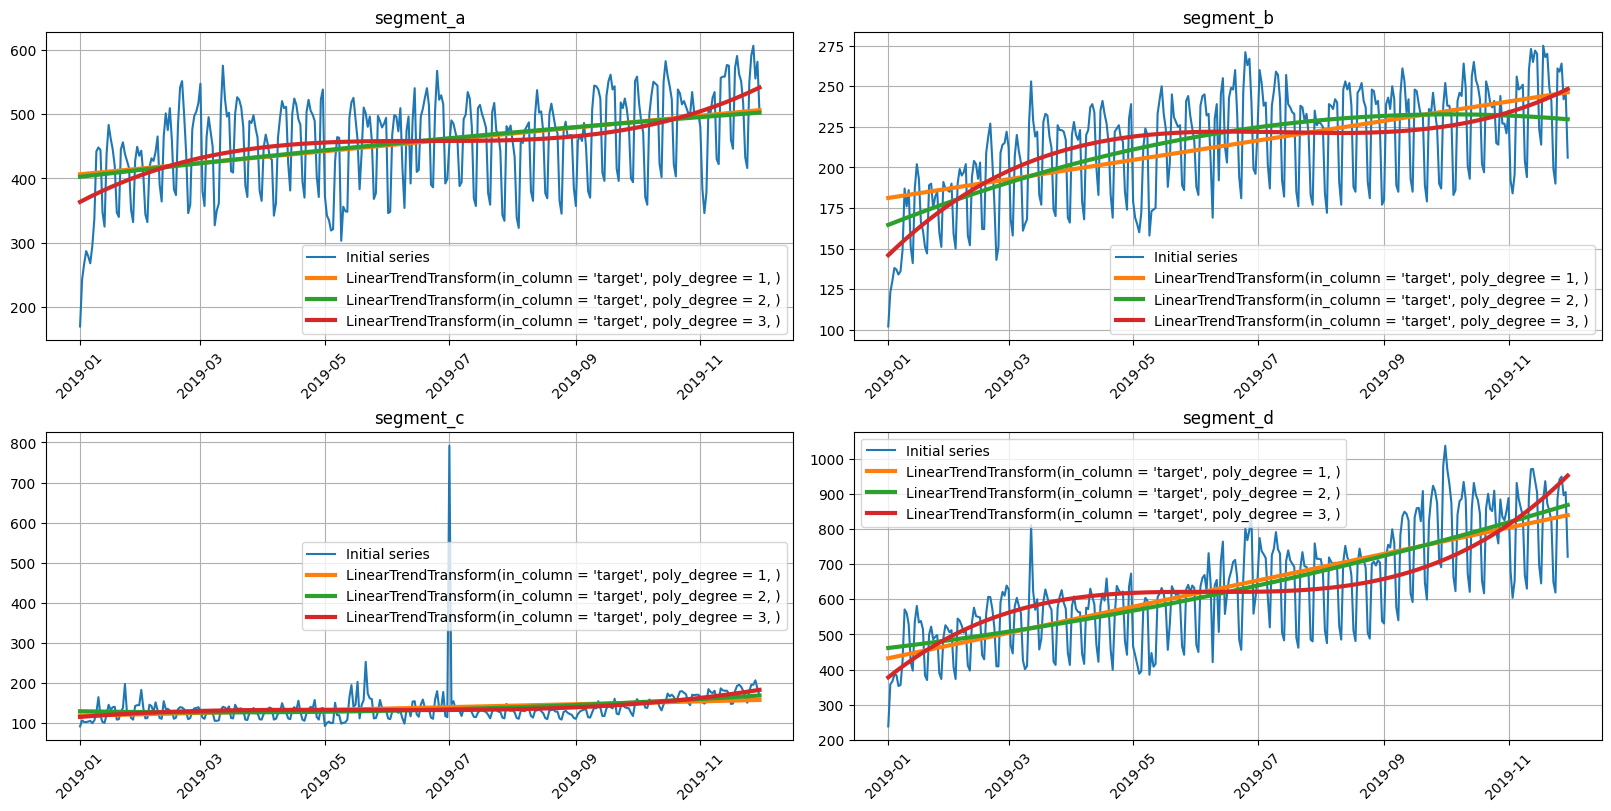

In [32]:
plot_trend(
    ts,
    trend_transform=trends,
    figsize=(8,4)
)

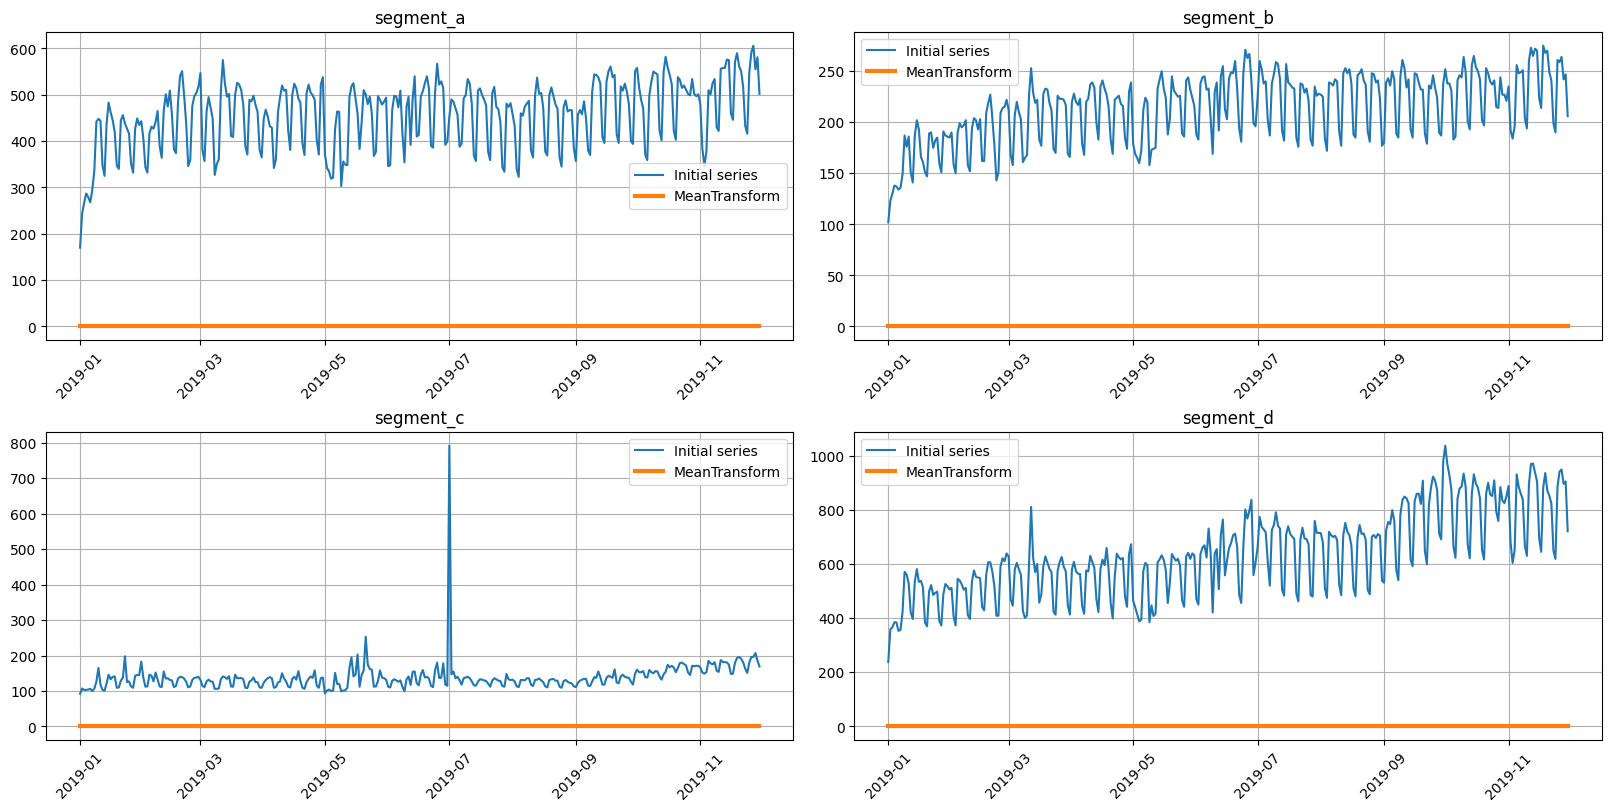

In [36]:
from etna.analysis import plot_trend
from etna.transforms import MeanTransform

# Скользящее среднее с окном 30 дней как "тренд"
plot_trend(
    ts,
    trend_transform=MeanTransform(in_column="target", window=30, out_column="trend"),
    figsize=(8,4)
)

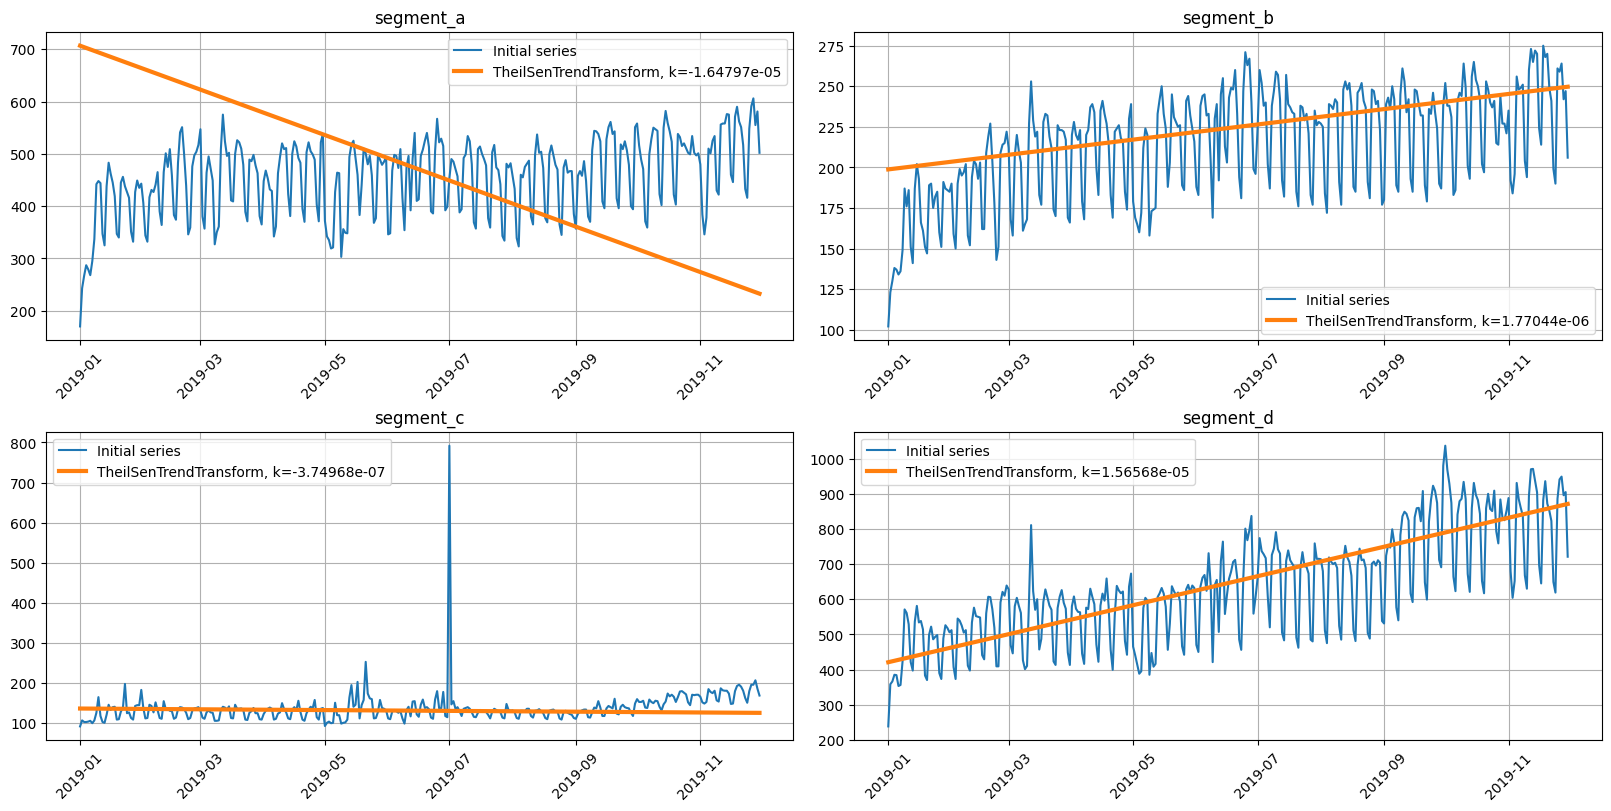

In [42]:
from etna.analysis import plot_trend
from etna.transforms import TheilSenTrendTransform

# Робастная альтернатива обычной линейной регрессии
plot_trend(
    ts,
    trend_transform=TheilSenTrendTransform(in_column="target"),
    figsize=(8,4)
)

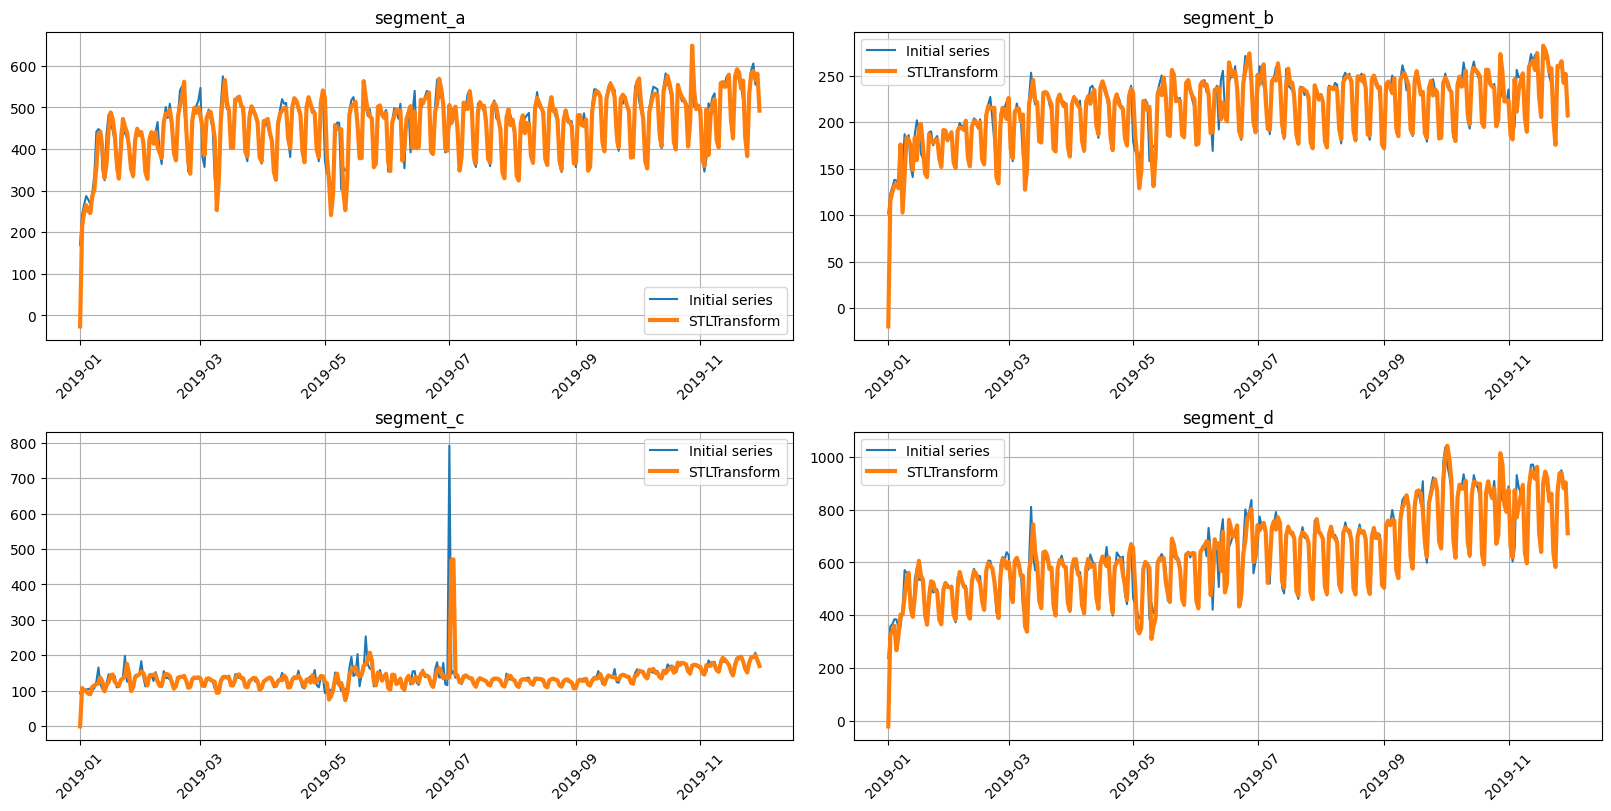

In [45]:
from etna.analysis import plot_trend
from etna.transforms import STLTransform

# STL: выделяет гладкий тренд, учитывая сезонность
trend = STLTransform(
    in_column="target",
    period=7,            # длина сезона (12 = месячные данные → годовая сезонность)
    robust=True           # устойчивость к выбросам
)

plot_trend(
    ts,
    trend_transform=trend,
    figsize=(8,4)
)

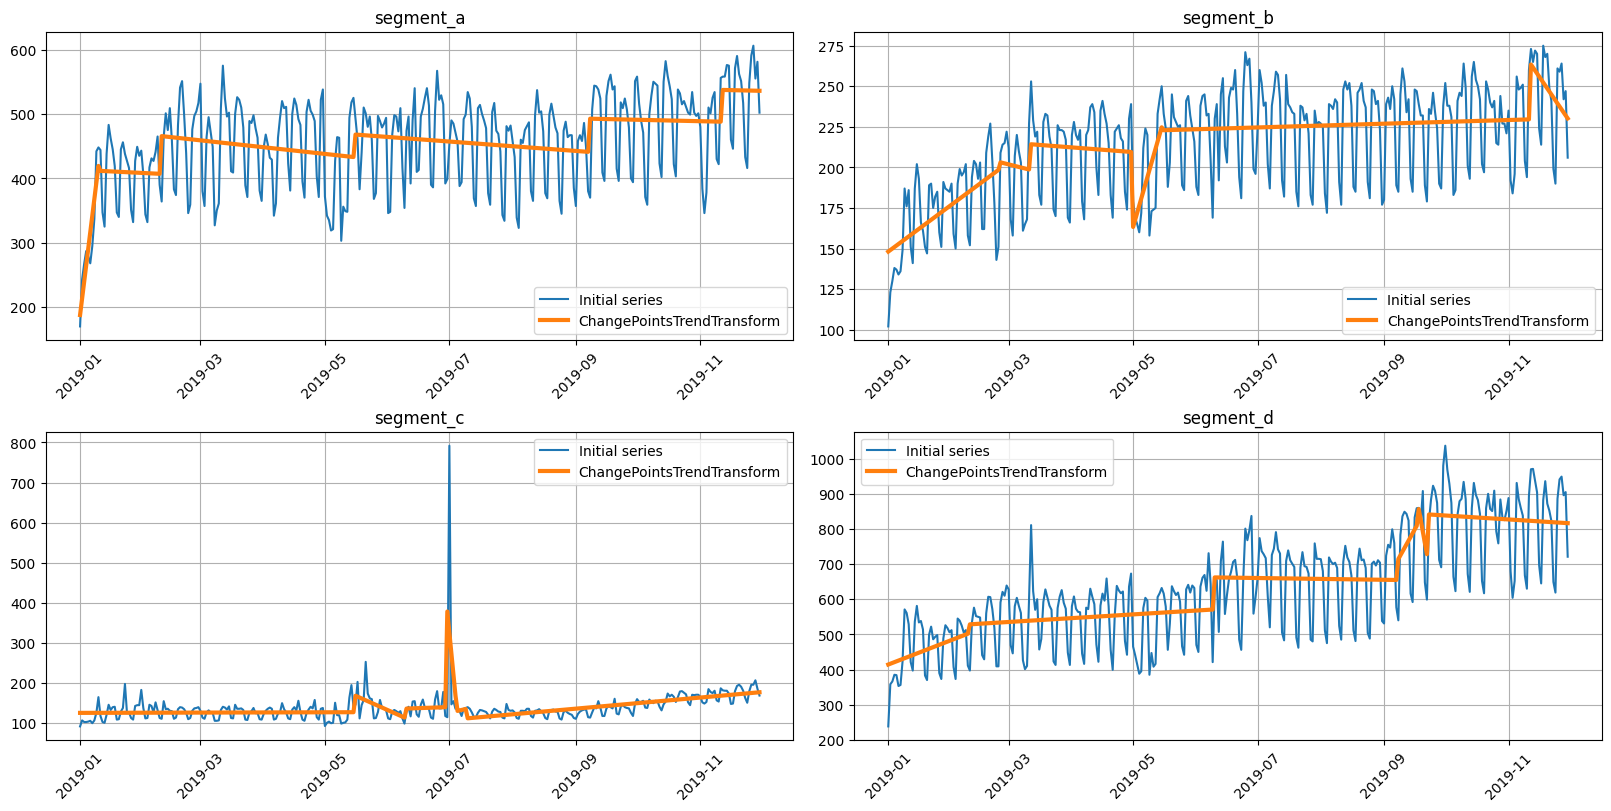

In [47]:
from etna.transforms import ChangePointsTrendTransform

# Автоматически находит точки, где тренд "ломается", и строит кусочно-линейный тренд
plot_trend(
    ts,
    trend_transform=ChangePointsTrendTransform(in_column="target"),
    figsize=(8,4)
)

### 2.7 Seasonality <a class="anchor" id="section_2_7"></a>

Our library provide several methods for seasonality analysis.

In [ ]:
from etna.analysis import plot_periodogram
from etna.analysis import seasonal_plot
from etna.analysis import stl_plot

The first one, `plot_periodogram` visualize the amplitudes of the fourier components inside the `period`. This method might be useful determine the `order` parameter in `FourierTransform` . The rule of thumb is to set the `order` as the last significant pick of amplitude.

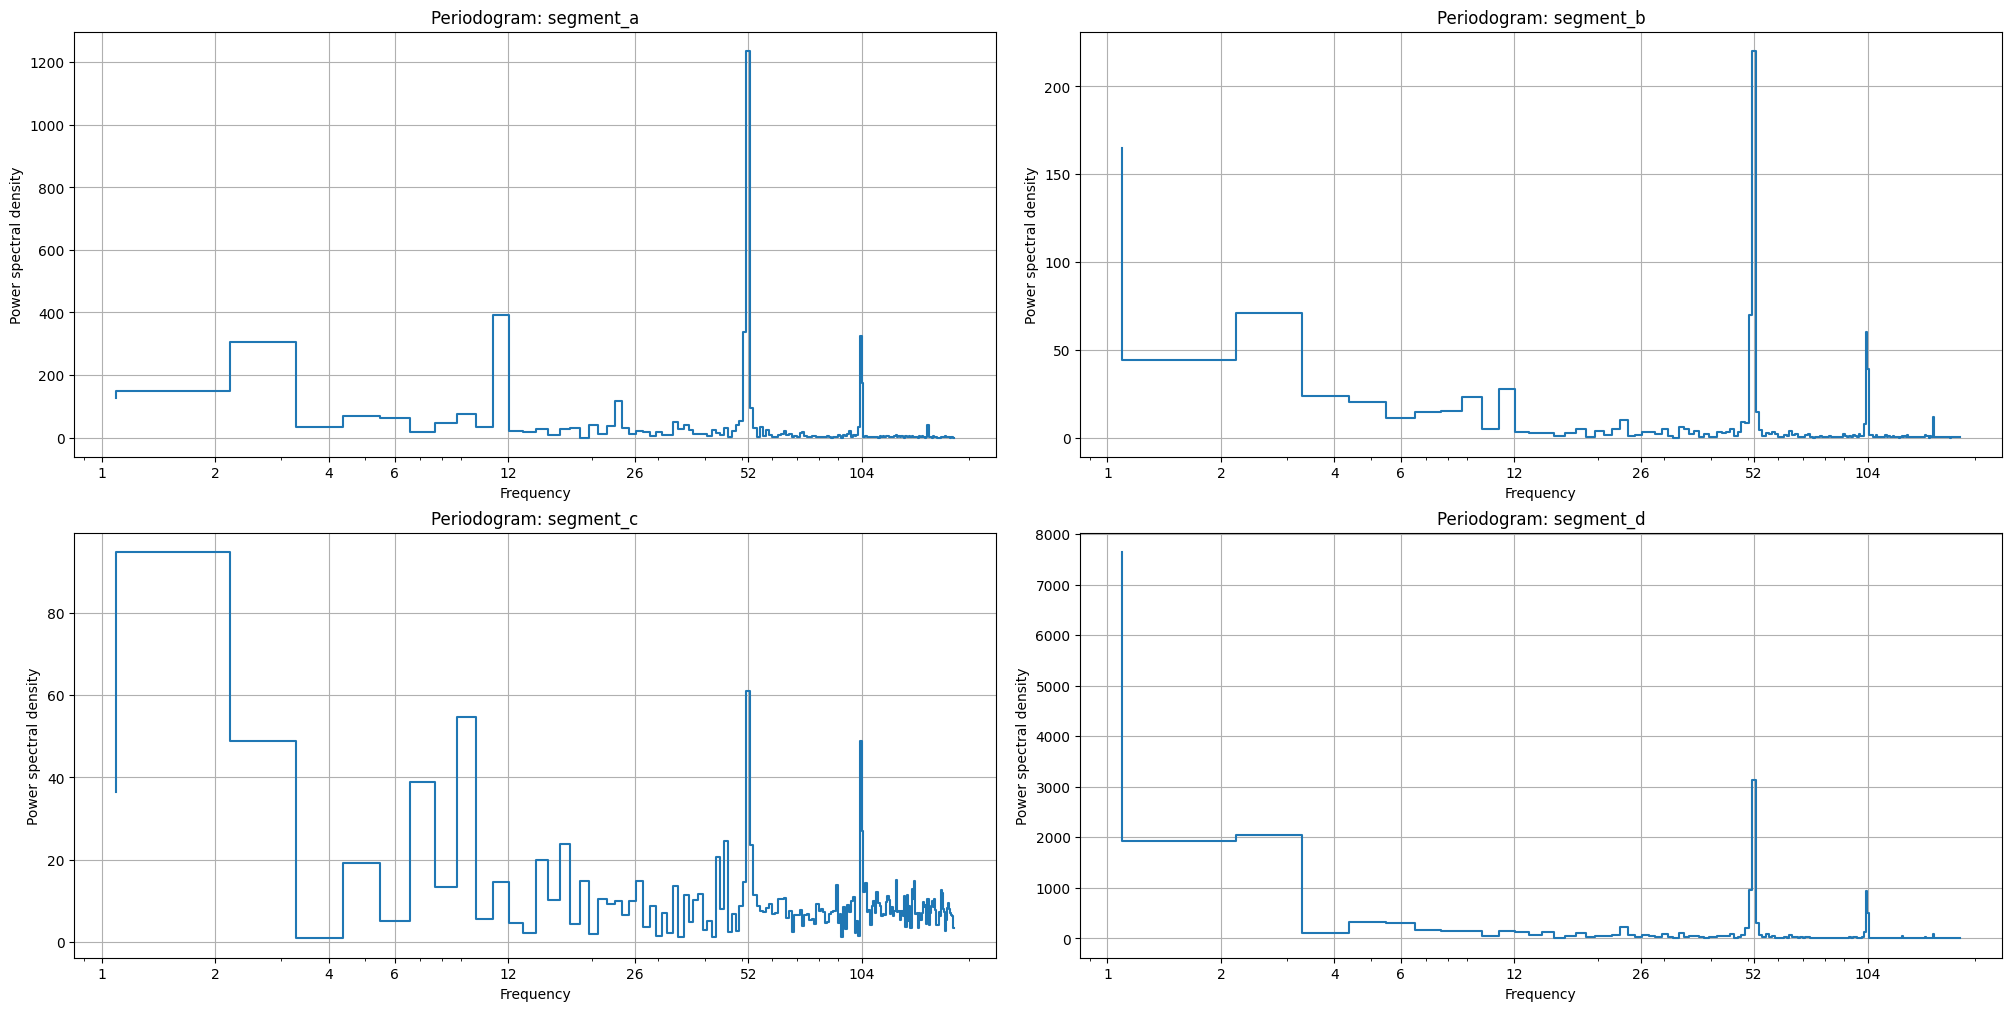

In [ ]:
plot_periodogram(ts, period=365.2425, amplitude_aggregation_mode="per-segment", xticks=[1, 2, 4, 6, 12, 26, 52, 104])

The second one, pics in the periodogram also shows the existence of corresponding seasonality, i.e. pick near x=52 shows the weekly seasonality (52 times a year).

`stl_plot` is a visualization of the corresponding decomposition

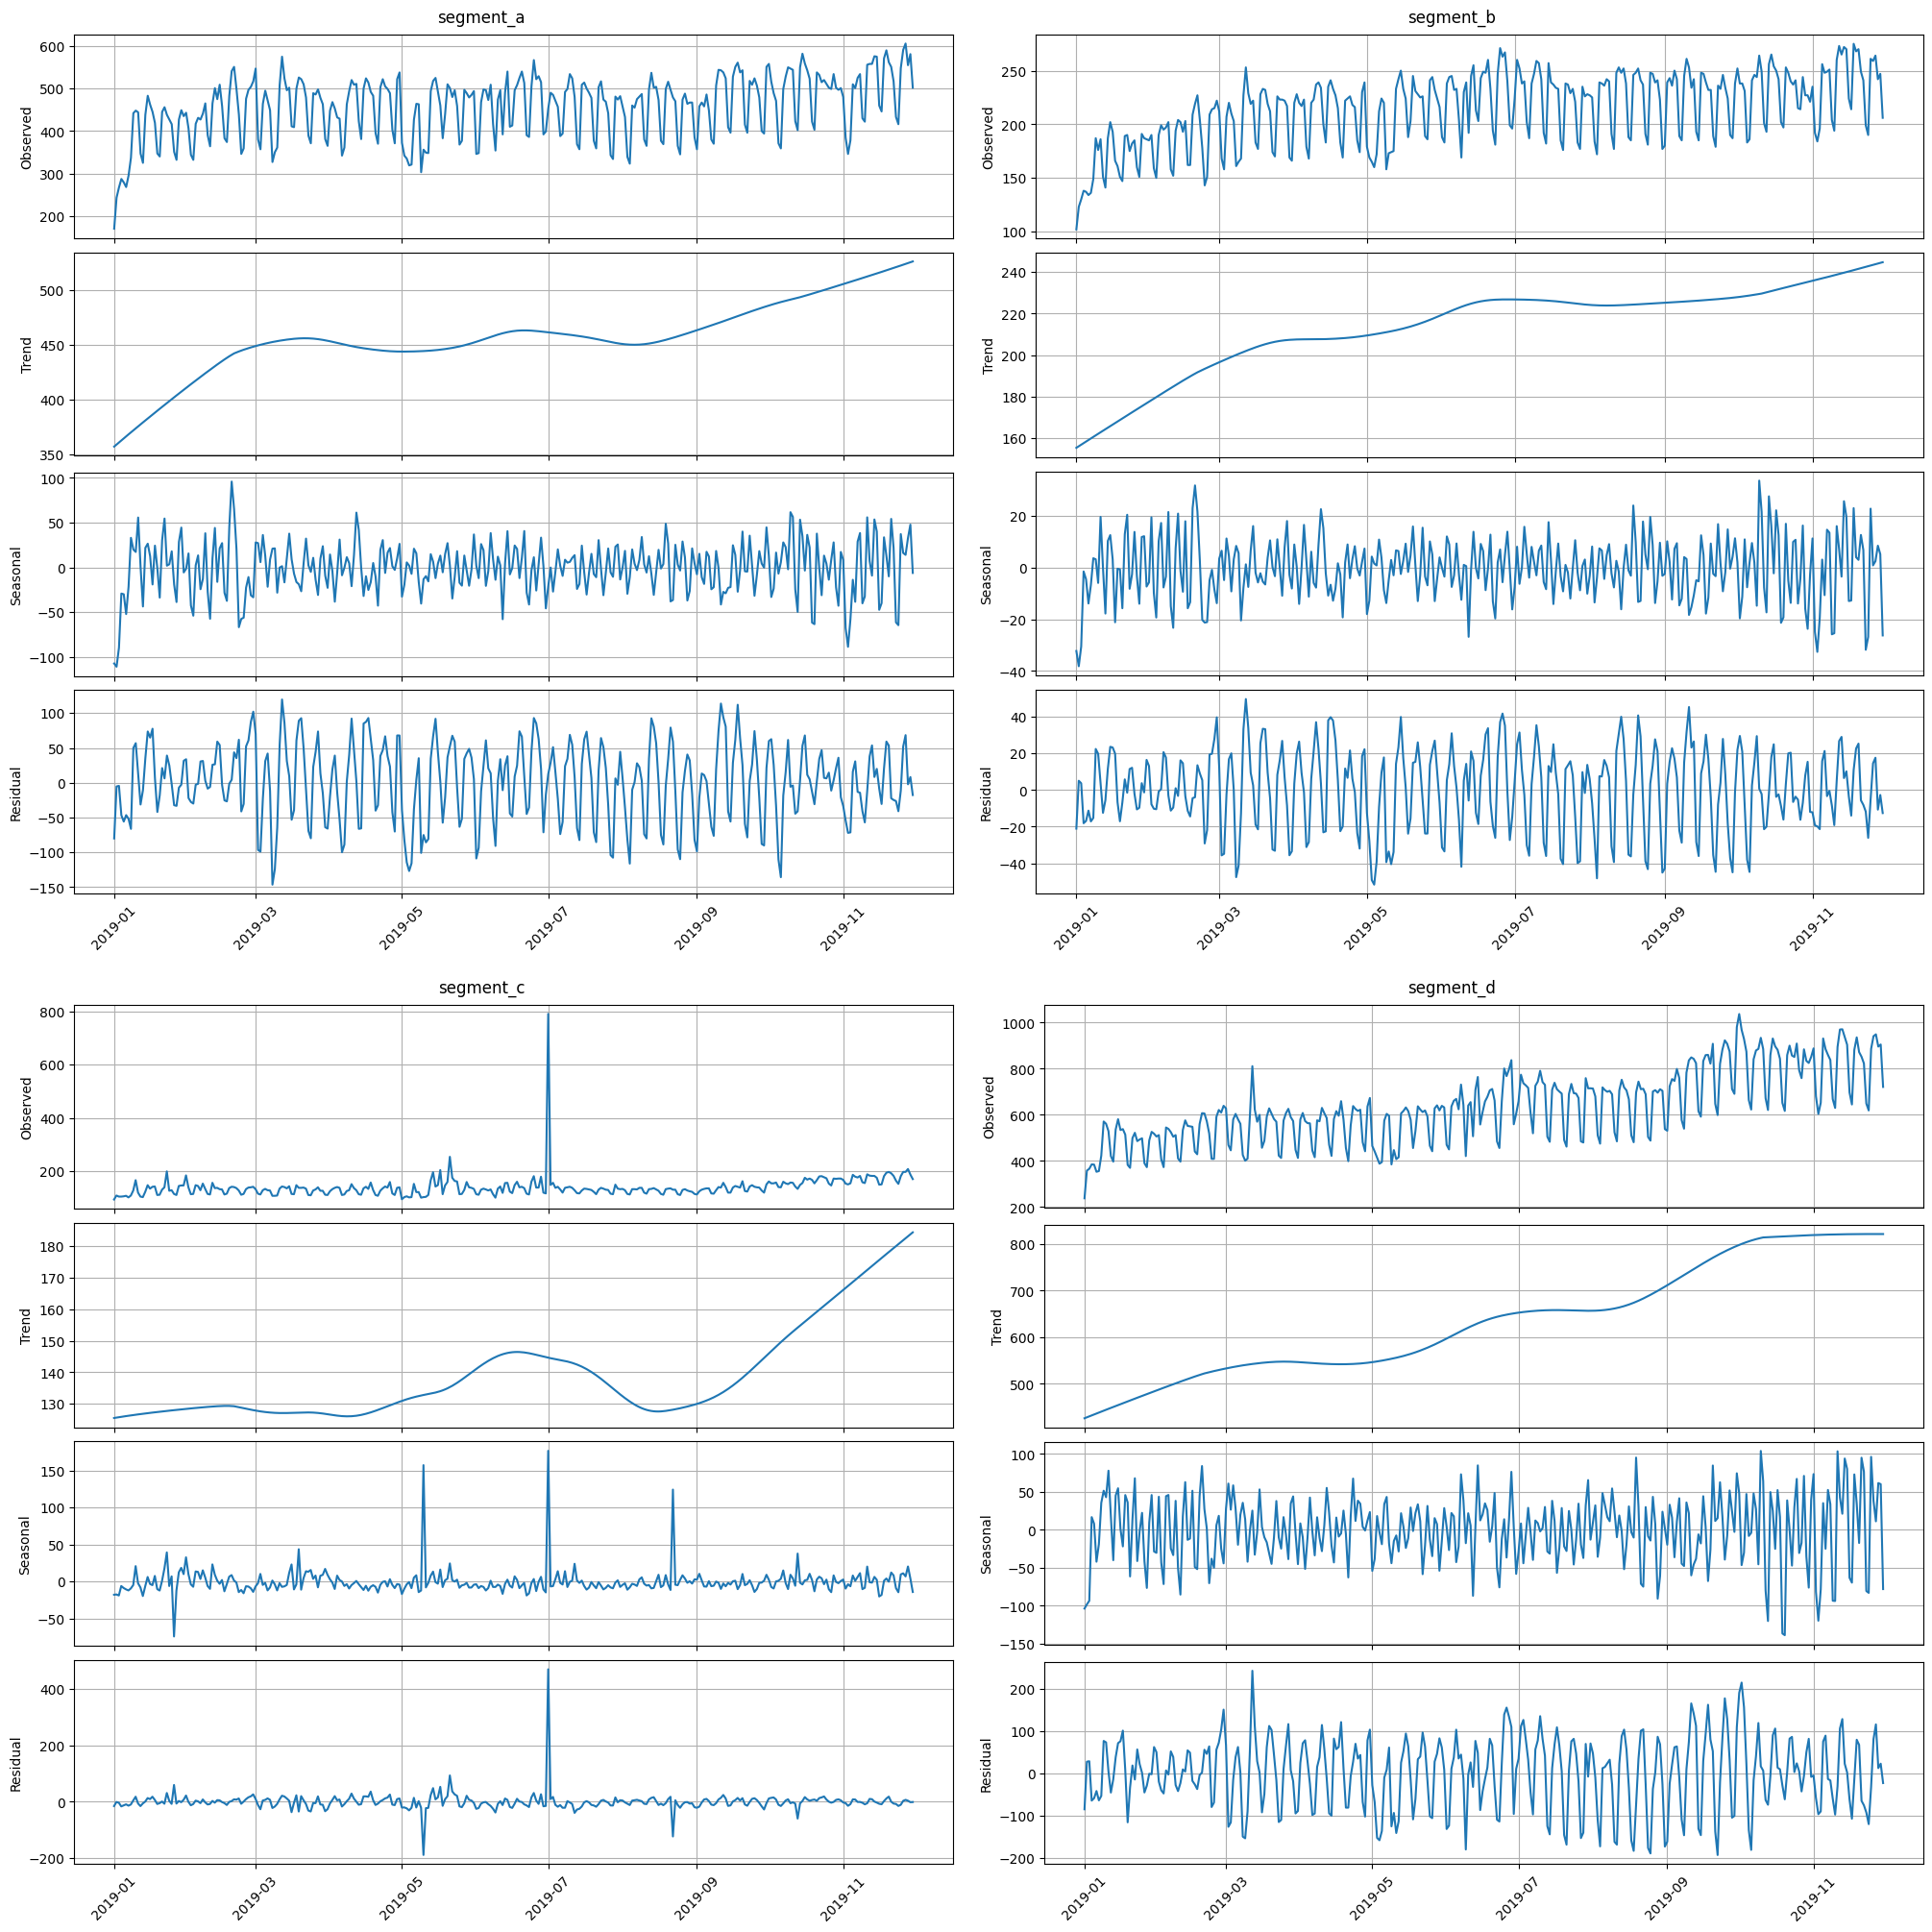

In [ ]:
stl_plot(ts=ts, period=52)

The third one, `seasonal_plot` helps to visualize the a specific period of seasonality (hour, day, week, month, quarter, year). A `seasonal_plot` allows the underlying seasonal pattern to be seen more clearly, and is especially useful in identifying periods in which the pattern changes

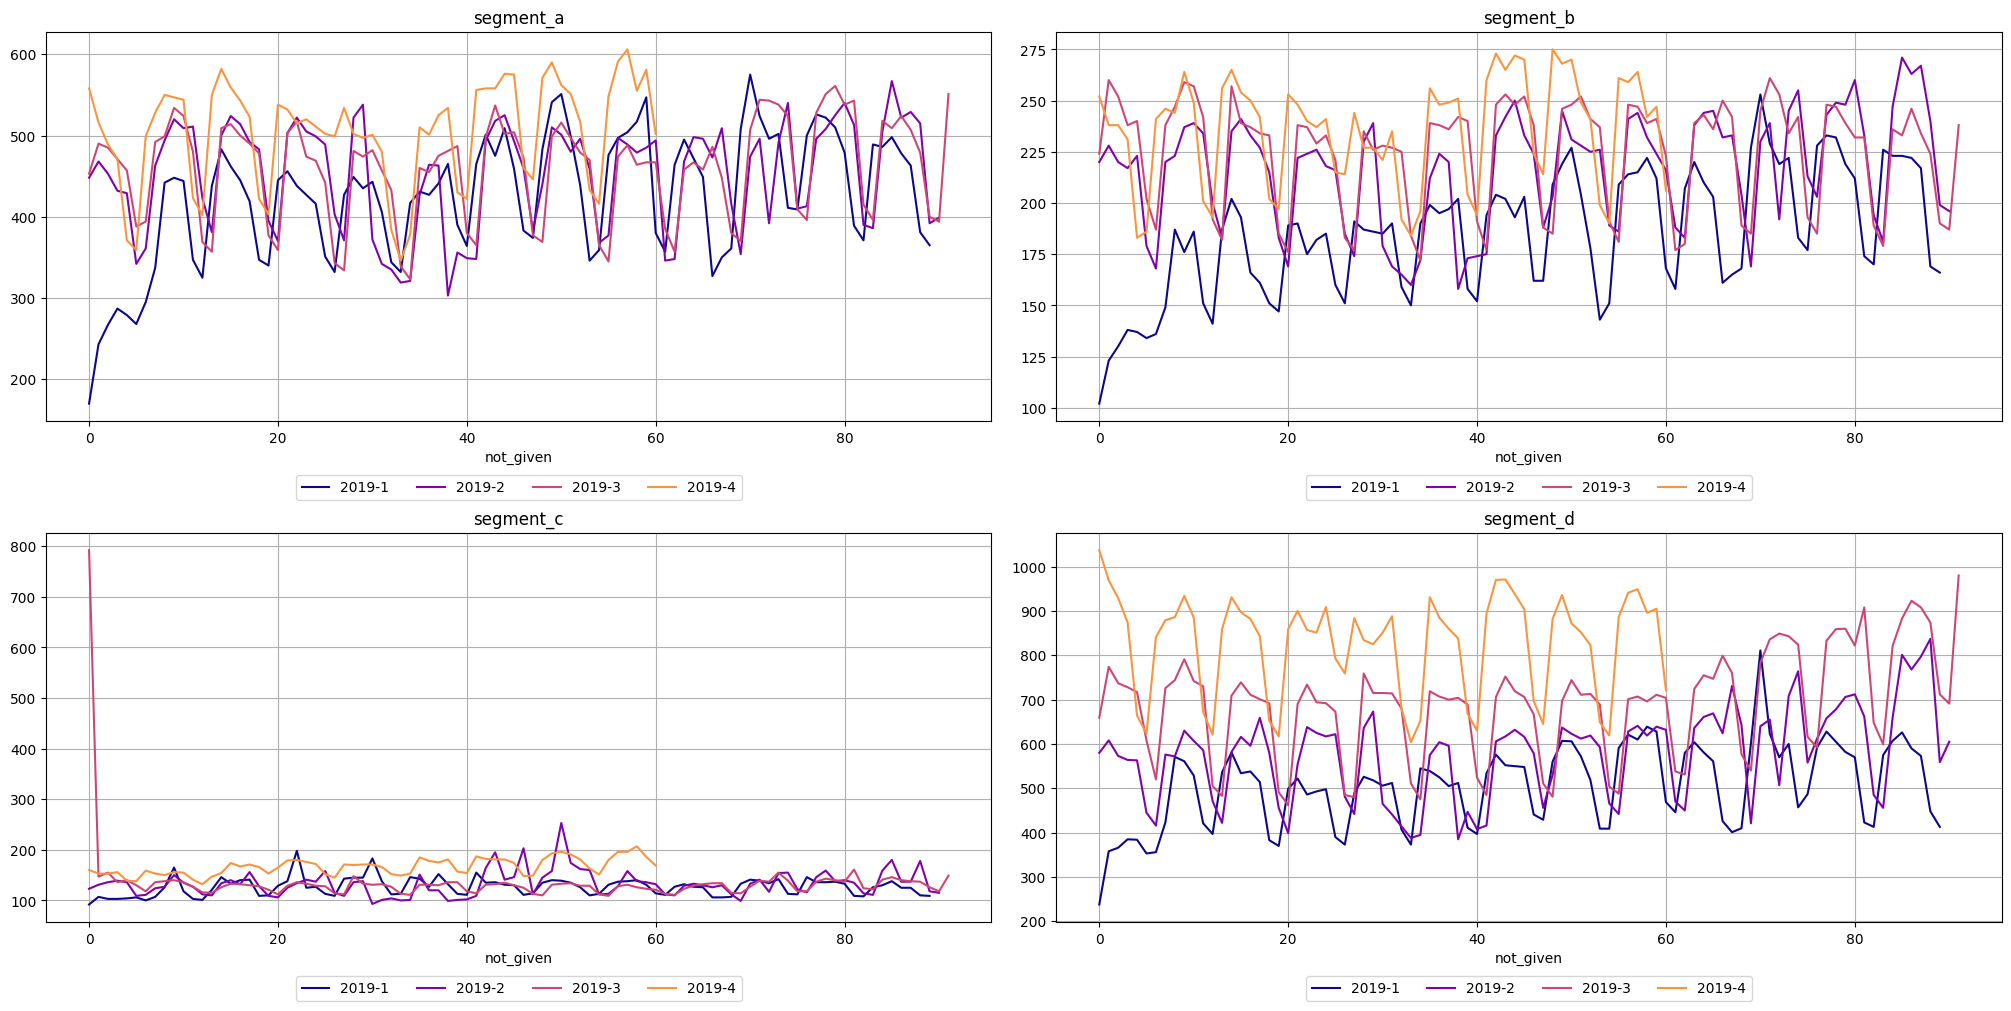

In [ ]:
seasonal_plot(ts=ts, cycle="quarter")

## 3. Outliers <a class="anchor" id="chapter3"></a>

Visually, all the time series contain outliers - abnormal spikes on the plot. Their presence might cause the reduce in predictions quality.

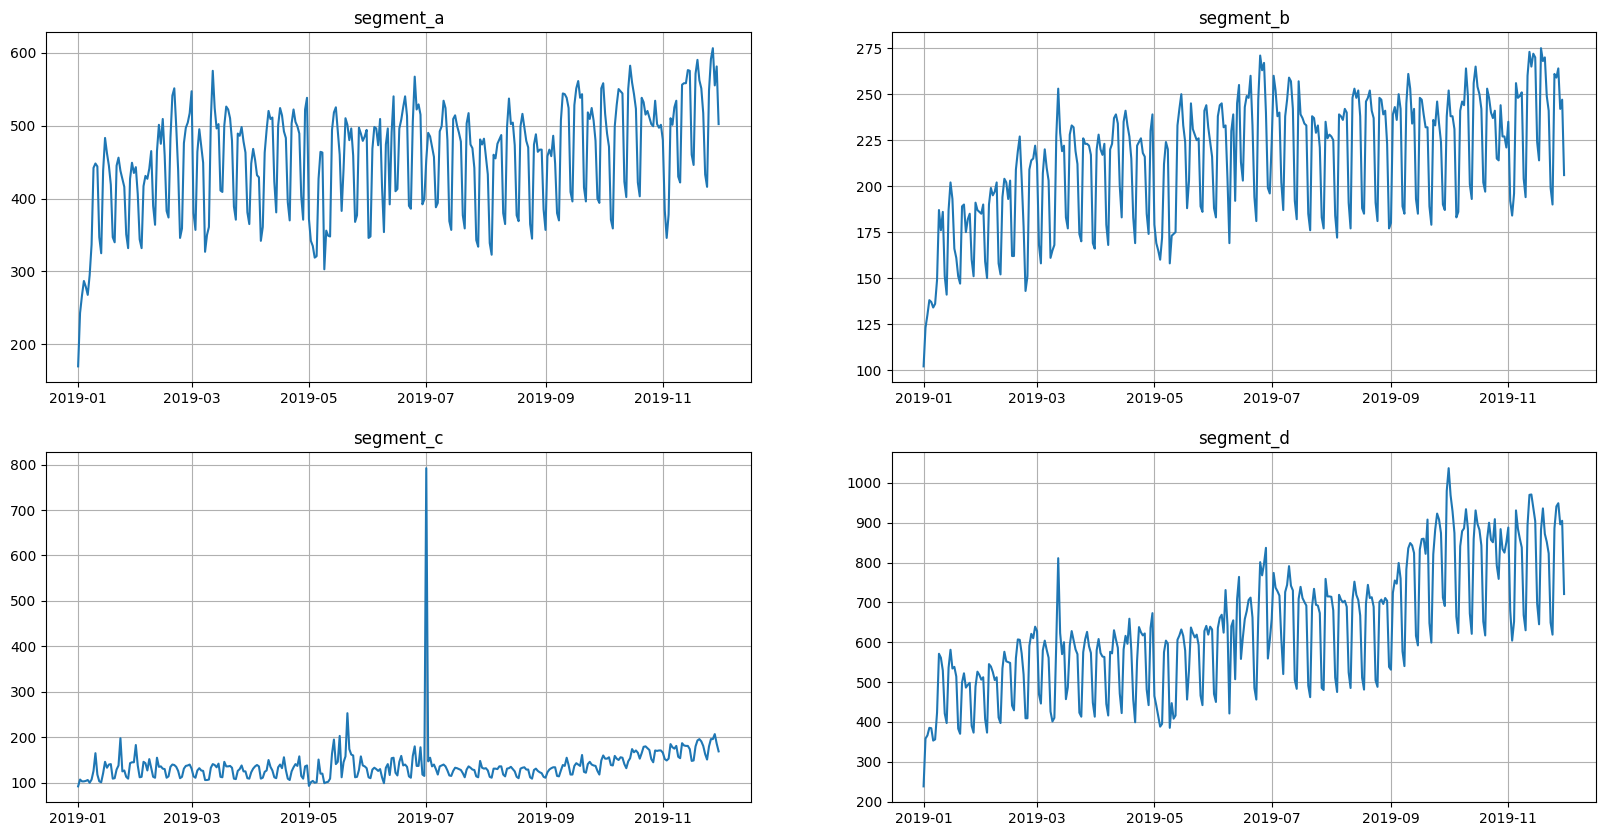

In [ ]:
ts.plot()

In our library, we provide two methods for outliers detection. In addition, you can easily visualize the detected outliers using ```plot_anomalies```


In [ ]:
from etna.analysis import get_anomalies_density
from etna.analysis import get_anomalies_median
from etna.analysis import plot_anomalies

### 3.1 Median method<a class="anchor" id="section_3_1"></a>

To obtain the point outliers using the median method we need to specify the *window* for fitting the median model.

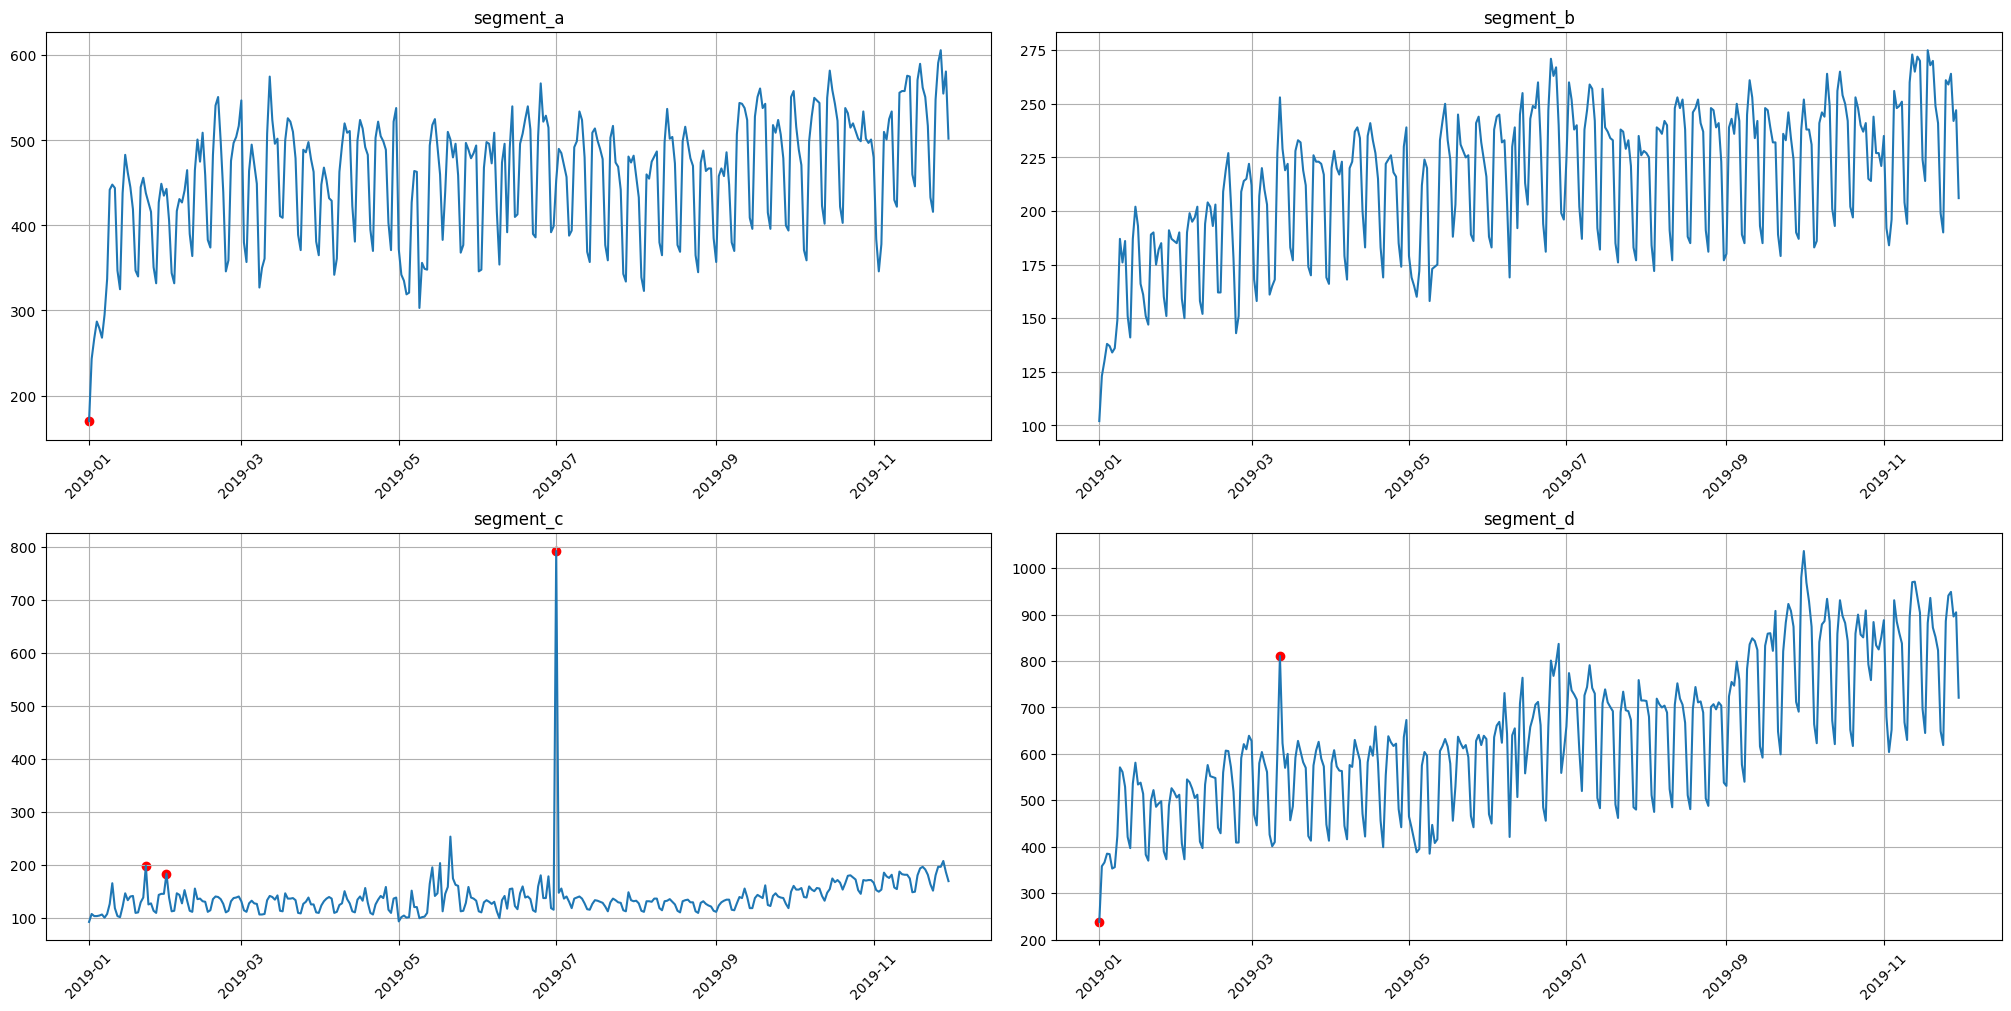

In [ ]:
anomaly_dict = get_anomalies_median(ts, window_size=100)
plot_anomalies(ts, anomaly_dict)

### 3.2 Density method<a class="anchor" id="section_3_2"></a>

It is a distance-based method for outliers detection. Don't rely on default parameters)

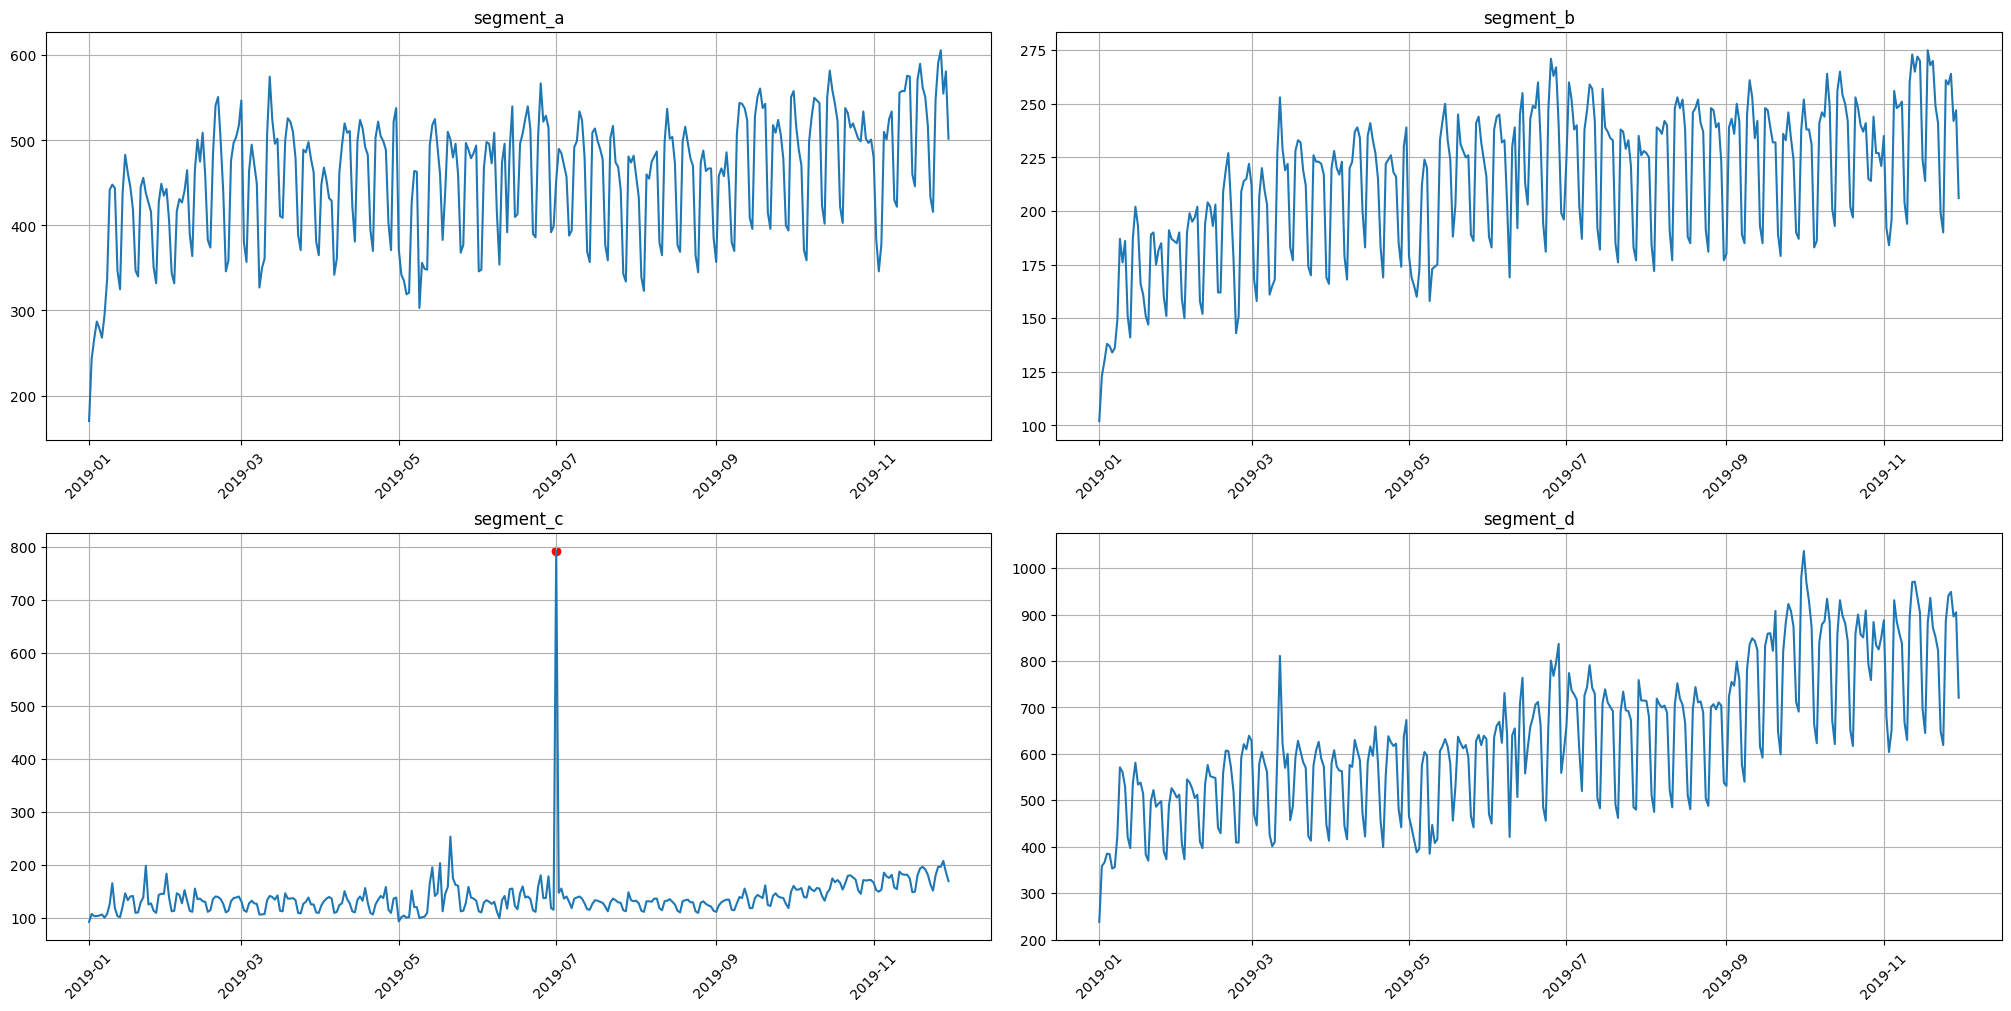

In [ ]:
anomaly_dict = get_anomalies_density(ts)
plot_anomalies(ts, anomaly_dict)

The best practice here is to specify the method parameters for your data

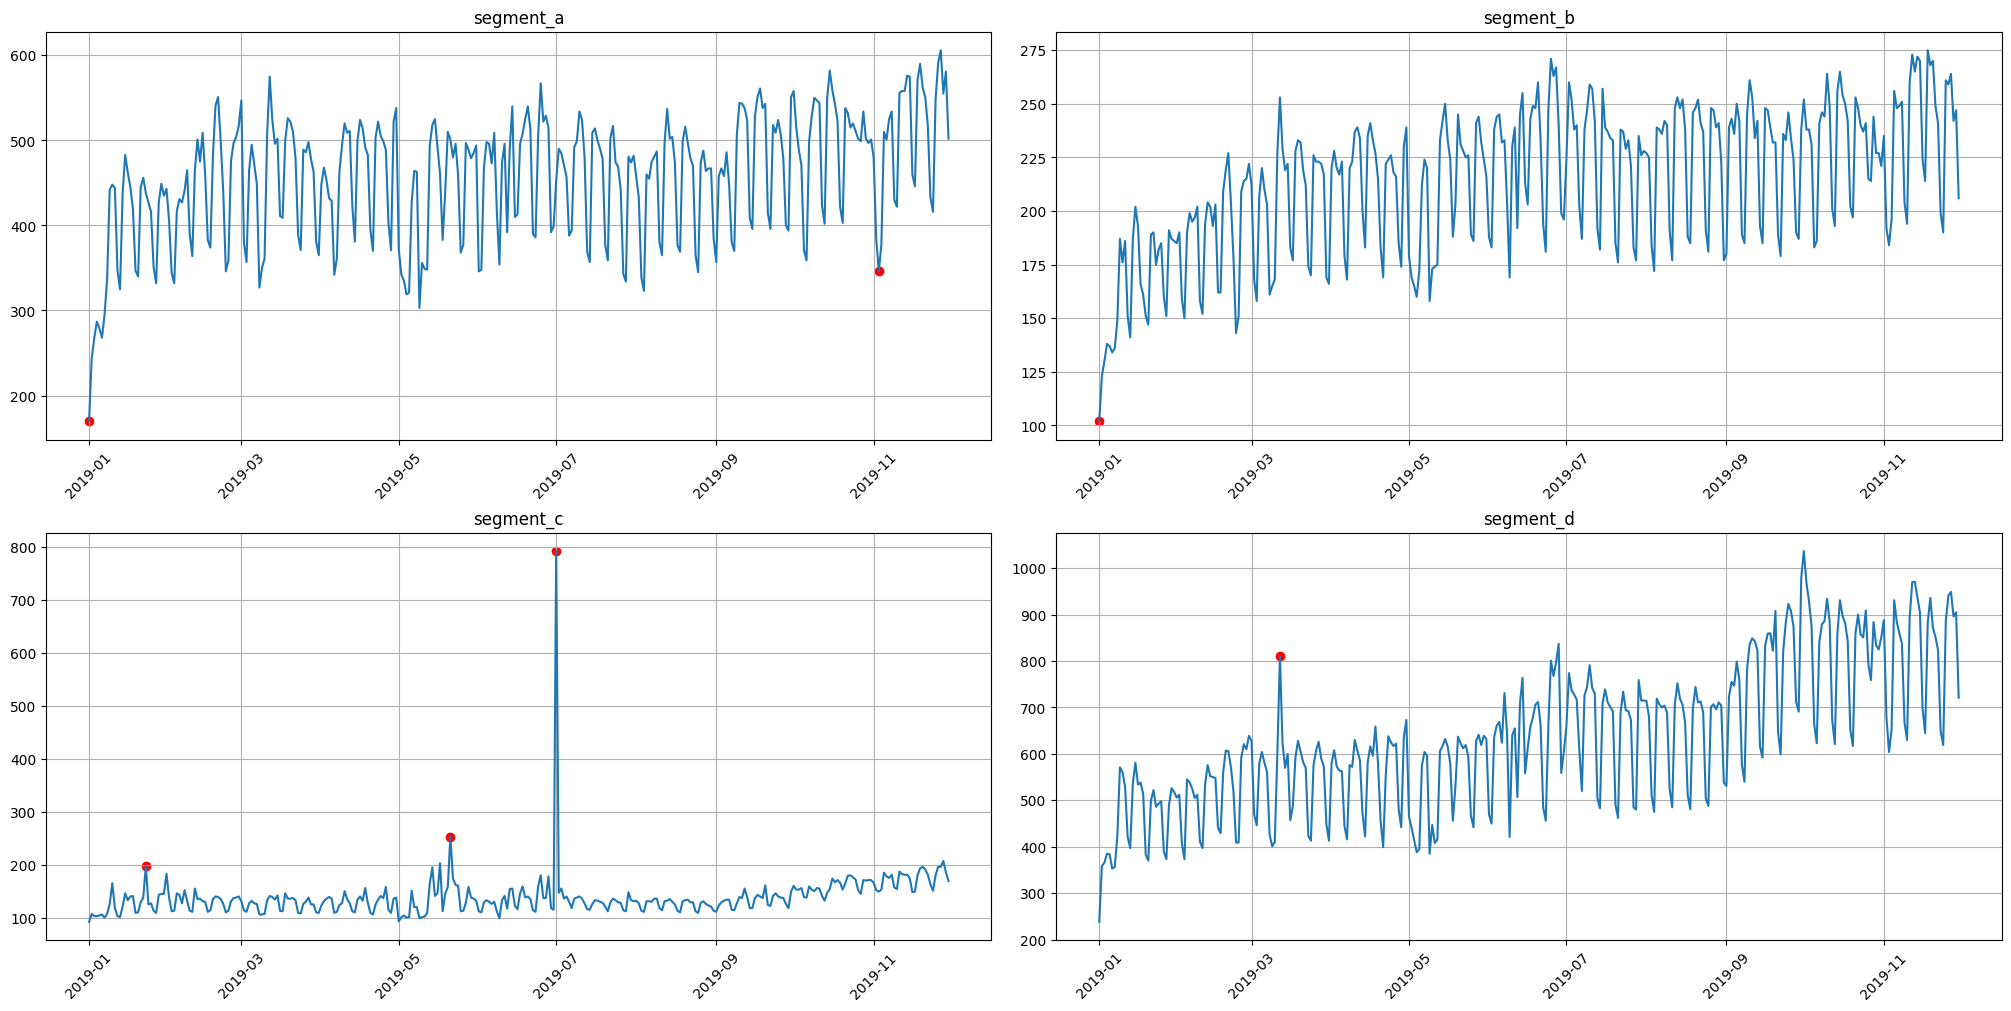

In [ ]:
anomaly_dict = get_anomalies_density(ts, window_size=18, distance_coef=1, n_neighbors=4)
plot_anomalies(ts, anomaly_dict)

## 4. Change Points <a class="anchor" id="chapter4"></a>

Sometimes the series contains trend changes in history. Identification and processing of trends taking into account changes can help in forecasting

In our library we provide 2 methods for visualization change points

In [ ]:
from ruptures.detection import Binseg

from etna.analysis import find_change_points
from etna.analysis import plot_change_points_interactive
from etna.analysis import plot_time_series_with_change_points

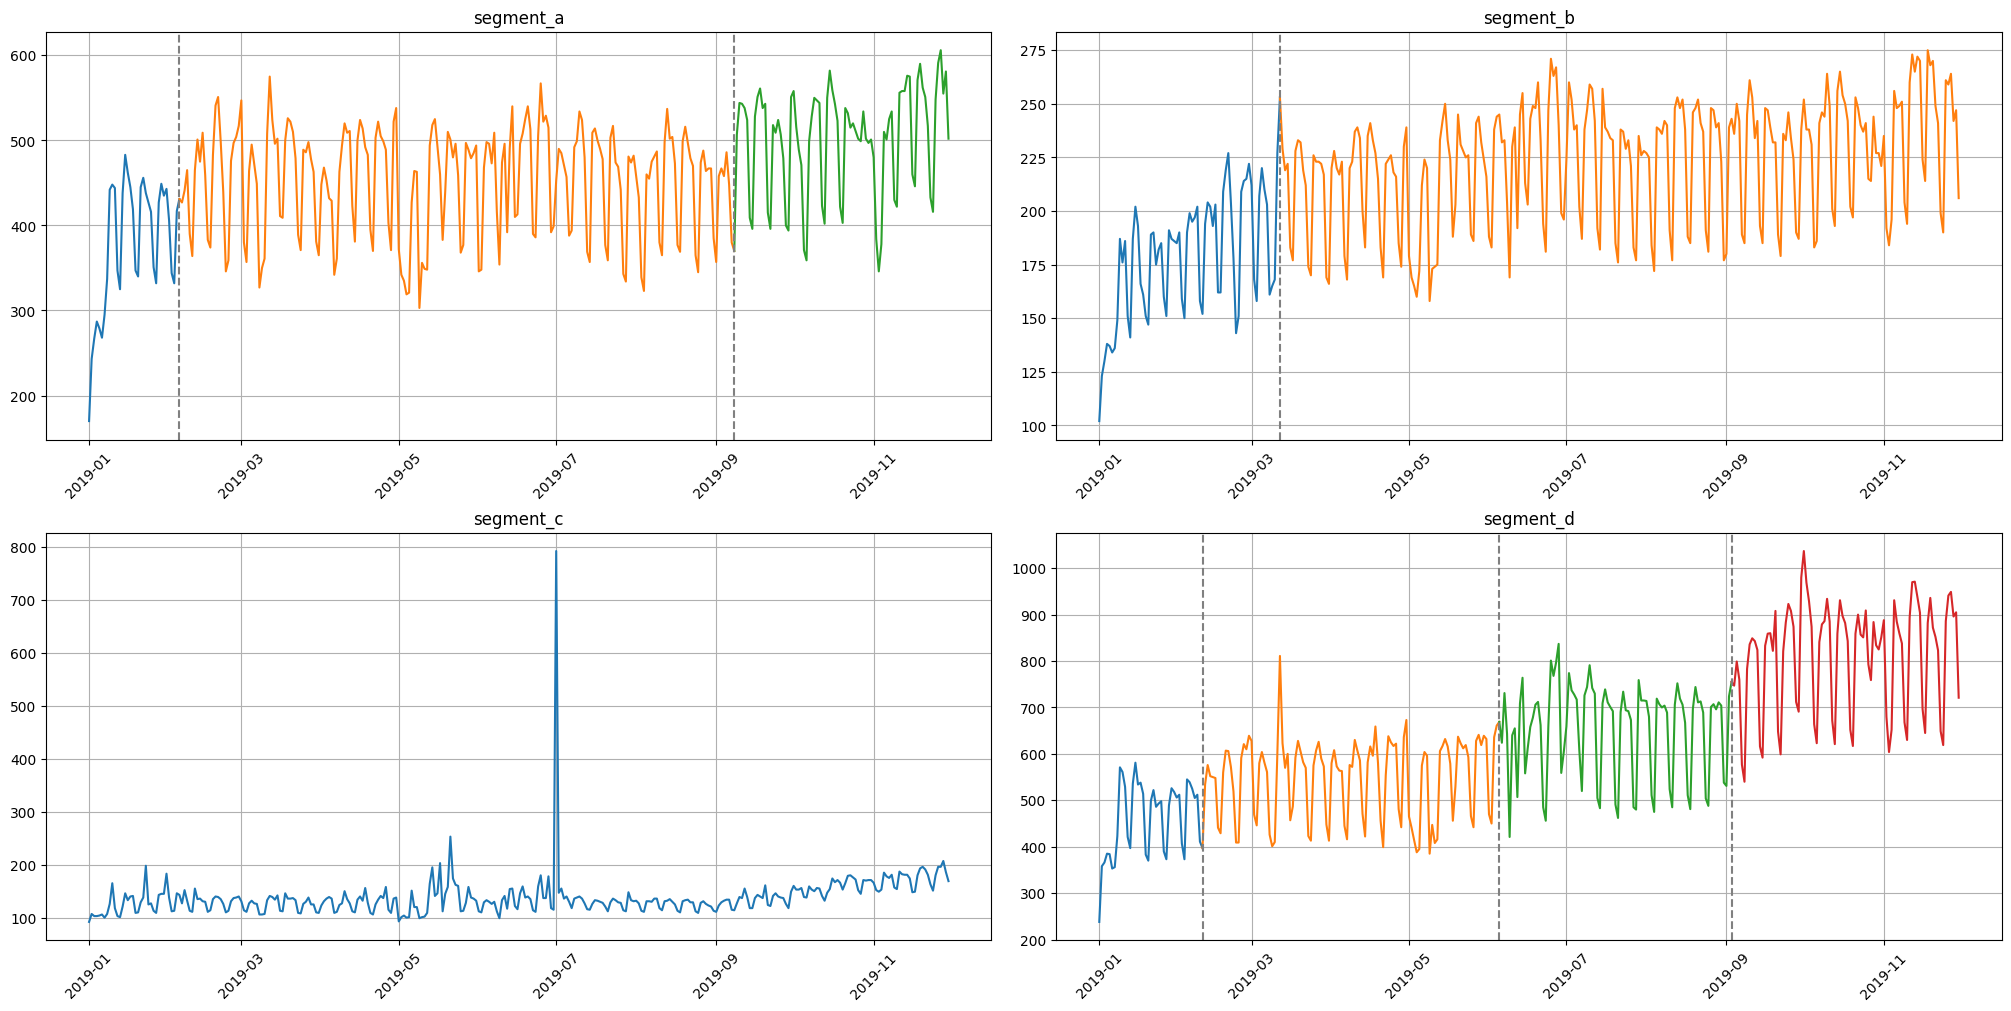

In [ ]:
change_points = find_change_points(ts=ts, in_column="target", change_point_model=Binseg(), pen=1e5)
plot_time_series_with_change_points(ts=ts, change_points=change_points)

For better initialization parameters there are exist interactive EDA method.

In some cases there might be troubles with this visualisation in Jupyter notebook, try to use ```!jupyter nbextension enable --py widgetsnbextension```

In [ ]:
params_bounds = {"n_bkps": [0, 8, 2], "min_size": [1, 10, 3]}
plot_change_points_interactive(
    ts=ts,
    change_point_model=Binseg,
    model="l2",
    params_bounds=params_bounds,
    model_params=["min_size"],
    predict_params=["n_bkps"],
    figsize=(20, 10),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='n_bkps', max=8, step=2, style=S…

That's all for this notebook. More features for time series analysis you can find in our documentation.